<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> Analysis Notebook</h1>

## Stable and Unstable Predictors Among Tree-Based Models — Kendall's W

## Reproducibility

This notebook is part of the analysis for the associated research paper.

All computations were performed in a controlled Python environment exported in:
- `environment.yml`

To recreate the environment:

```
conda env create -f environment.yml
```

Then run all cells in this notebook.

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 1. Import packages</h1>

In [1]:
# stdlib
import os
import re
from itertools import combinations

# core
import numpy as np
import pandas as pd
from numpy import mean
from scipy.special import softmax
from scipy.stats import rankdata

# viz
from matplotlib import pyplot as plt
%matplotlib inline

# features
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# models
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# validation
from sklearn.model_selection import StratifiedKFold

# metrics
from sklearn.metrics import (
    accuracy_score, auc, brier_score_loss, classification_report,
    confusion_matrix, f1_score, log_loss,
    precision_score, recall_score,
    roc_auc_score, roc_curve)

# xgb
import xgboost as xgb

# stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# shap
import shap
shap.initjs()

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 2. Configuration</h1>

In [49]:
output_path = "results" #make your own
seed = 9401

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 3. Helper functions</h1>

In [3]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    # Check if model is an xgboost.Booster (low-level API)
    is_xgboost_booster = isinstance(model, xgb.Booster)

    if is_xgboost_booster:
        # Assume X_train and X_test are already DMatrix
        y_train_proba = model.predict(X_train)
        y_test_proba = model.predict(X_test)

        # Threshold for binary classification
        y_train_pred = (y_train_proba >= 0.5).astype(int)
        y_test_pred = (y_test_proba >= 0.5).astype(int)
    else:
        # Standard scikit-learn estimator
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    # TRAIN metrics
    print("TRAIN SET METRICS:")
    print(f" Accuracy : {accuracy_score(y_train, y_train_pred):.3f}")
    print(f" Precision: {precision_score(y_train, y_train_pred):.3f}")
    print(f" Recall   : {recall_score(y_train, y_train_pred):.3f}")
    print(f" F1 Score : {f1_score(y_train, y_train_pred):.3f}")
    print(f" AUC      : {roc_auc_score(y_train, y_train_proba):.3f}\n")

    # TEST metrics
    print("TEST SET METRICS:")
    print(f" Accuracy : {accuracy_score(y_test, y_test_pred):.3f}")
    print(f" Precision: {precision_score(y_test, y_test_pred):.3f}")
    print(f" Recall   : {recall_score(y_test, y_test_pred):.3f}")
    print(f" F1 Score : {f1_score(y_test, y_test_pred):.3f}")
    print(f" AUC      : {roc_auc_score(y_test, y_test_proba):.3f}\n")

    # Plot ROC curves
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {roc_auc_score(y_train, y_train_proba):.3f})')
    plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {roc_auc_score(y_test, y_test_proba):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Train vs Test')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

In [85]:
# Prints the feature importances
def print_feature_importances_random_forest(model,dataset):
    
    feature_names = dataset.columns.values
    importances = model.feature_importances_
    forest_importance = pd.Series(importances, index=feature_names)
    
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1]
    sorted_features = np.array(feature_names)[sorted_idx]
    sorted_importance = importance[sorted_idx]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(sorted_importance)), sorted_importance, color='skyblue')
    plt.yticks(range(len(sorted_importance)), sorted_features, fontsize=9)
    plt.xlabel("Importance")
    plt.title(f'Mean Decrease in Impurity')
    plt.gca().invert_yaxis()  # highest importance at the top

    # add value labels to bars
    for i, (bar, value) in enumerate(zip(bars, sorted_importance)):
        plt.text(value + 0.00005, bar.get_y() + bar.get_height()/2,
                 f"{value:.3f}", va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 4. Load and prepare dataset </h1>

In [5]:
data_elder = pd.read_sas('data_elder.sas7bdat', encoding='LATIN2')

In [6]:
data_elder = data_elder.sort_values(by=['mergeid'], ascending=[True])
# Drop rows where column 'HH_ID' has duplicated values
data_elder = data_elder[~data_elder['mergeid'].duplicated(keep='first')]
data_elder.shape

(5311, 53)

In [7]:
data_elder.columns

Index(['mergeid', 'total_income_mean', 'country', 'YrBirth', 'MaritalStat',
       'IntCheck', 'YearsEdu', 'Gender', 'gt65', 'gt75', 'age', 'HasBankAcc',
       'CurrentJobSit', 'EmployeeOrSelf', 'RiskAv', 'HowSat', 'AgePrev',
       'OutofContr', 'DoWant', 'FamRespPrev', 'ShortMon', 'LifeMean',
       'FullEnerg', 'PC_skill', 'UseWWW', 'NChildren', 'HealthGen2', 'LStill',
       'LimAct', 'LimPaidWork', 'implicat', 'ear_emp', 'ear_self_emp',
       'retirement', 'priv_pension', 'disab_pension', 'unemply_pension',
       'social_assis', 'sick_benefit', 'liab', 'HasBankAcc_bin',
       'total_income', 'EmployeeOrSelf_bin', 'NChildren_bin',
       'LimPaidWork_bin', 'DoWant_bin', 'OutofContr_bin', 'AgePrev_bin',
       'FamRespPrev_bin', 'ShortMon_bin', 'LifeMean_bin', 'FullEnerg_bin',
       'HowSatis'],
      dtype='object')

In [8]:
# Rename target variable
data_elder = data_elder.rename(columns={'HasBankAcc_bin': 'target'})

In [9]:
#drop some unnedded columns
data_elder = data_elder.drop(['mergeid','country','YrBirth','IntCheck','gt75','gt65','HasBankAcc','HowSat',
                              'priv_pension','retirement','disab_pension','sick_benefit','total_income',
                              'unemply_pension','social_assis','ear_emp','ear_self_emp','implicat'],axis=1)

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 5. Characteristics engeenering - inspection and binning </h1>

In [10]:
lstill_summary = data_elder.groupby(['LStill']).size().to_frame(name='count')
lstill_summary

,count
LStill,
0.0,2259
1.0,3052


In [11]:
useWWW_summary = data_elder.groupby(['UseWWW']).size().to_frame(name='count')
useWWW_summary

,count
UseWWW,
0.0,2553
1.0,2758


In [12]:
pcskill_summary = data_elder.groupby(['PC_skill']).size().to_frame(name='count')
pcskill_summary

,count
PC_skill,
1.0,157
2.0,416
3.0,1037
4.0,1065
5.0,795
6.0,1841


In [13]:
YearsEdu_summary = data_elder.groupby(['YearsEdu']).size().to_frame(name='count')
mean_target = data_elder.groupby('YearsEdu')['target'].mean().reset_index()
YearsEdu_summary = pd.merge(YearsEdu_summary, mean_target, on='YearsEdu')
YearsEdu_summary

,YearsEdu,count,target
0,0.0,33,0.545455
1,1.0,10,0.900000
2,2.0,24,0.500000
3,3.0,70,0.657143
4,4.0,175,0.480000
5,5.0,69,0.608696
6,6.0,176,0.664773
7,7.0,240,0.462500
8,8.0,624,0.650641
9,9.0,212,0.787736


In [14]:
maritalstat_summary = data_elder.groupby(['MaritalStat']).size().to_frame(name='count')
mean_target = data_elder.groupby('MaritalStat')['target'].mean().reset_index()
maritalstat_summary = pd.merge(maritalstat_summary, mean_target, on='MaritalStat')
maritalstat_summary
#1. Married and living together with spouse
#2. Registered partnership
#3. Married, living separated from spouse
#4. Never married
#5. Divorced
#6. Widowed

,MaritalStat,count,target
0,1.0,2792,0.782951
1,2.0,54,0.814815
2,3.0,63,0.730159
3,4.0,315,0.777778
4,5.0,498,0.843373
5,6.0,1589,0.665828


In [15]:
cjs_summary = data_elder.groupby(['CurrentJobSit']).size().to_frame(name='count')
mean_target = data_elder.groupby('CurrentJobSit')['target'].mean().reset_index()
cjs_summary = pd.merge(cjs_summary, mean_target, on='CurrentJobSit')
cjs_summary
#1. Retired
#2. Employed or self-employed (including working for family business)
#3. Unemployed
#4. Permanently sick or disabled
#5. Homemaker
#97. Other

,CurrentJobSit,count,target
0,1.0,4450,0.755056
1,2.0,406,0.864532
2,3.0,72,0.680556
3,4.0,88,0.602273
4,5.0,214,0.635514
5,97.0,81,0.617284


In [16]:
riskav_summary = data_elder.groupby(['RiskAv']).size().to_frame(name='count')
mean_target = data_elder.groupby('RiskAv')['target'].mean().reset_index()
riskav_summary = pd.merge(riskav_summary, mean_target, on='RiskAv')
riskav_summary
#1. Take substantial financial risks expecting to earn substantial returns
#2. Take above average financial risks expecting to earn above average returns
#3. Take average financial risks expecting to earn average returns
#4. Not willing to take any financial risks

,RiskAv,count,target
0,-2.0,20,0.450000
1,-1.0,131,0.580153
2,1.0,75,0.733333
3,2.0,132,0.863636
4,3.0,1039,0.916266
5,4.0,3914,0.713592


In [17]:
health_summary = data_elder.groupby(['HealthGen2']).size().to_frame(name='count')
mean_target = data_elder.groupby('HealthGen2')['target'].mean().reset_index()
health_summary = pd.merge(health_summary, mean_target, on='HealthGen2')
health_summary
#1. Excellent
#2. Very good
#3. Good
#4. Fair
#5. Poor

,HealthGen2,count,target
0,1.0,228,0.885965
1,2.0,584,0.854452
2,3.0,2098,0.792660
3,4.0,1719,0.717277
4,5.0,682,0.589443


In [18]:
howsat_summary = data_elder.groupby(['HowSatis']).size().to_frame(name='count')
mean_target = data_elder.groupby('HowSatis')['target'].mean().reset_index()
howsat_summary = pd.merge(howsat_summary, mean_target, on='HowSatis')
howsat_summary

,HowSatis,count,target
0,-1.0,69,0.507246
1,0.0,25,0.680000
2,1.0,11,0.818182
3,2.0,23,0.521739
4,3.0,55,0.527273
5,4.0,85,0.635294
6,5.0,471,0.626327
7,6.0,393,0.671756
8,7.0,734,0.700272
9,8.0,1574,0.800508


In [19]:
# Group by the categorical variables and count occurrences
ageprev_summary = data_elder.groupby(['AgePrev_bin']).size().to_frame(name='count')
ageprev_summary = ageprev_summary[ageprev_summary['count'] > 0]
ageprev_summary

,count
AgePrev_bin,
1.0,1017
2.0,1935
3.0,1226
4.0,1073
5.0,60


In [20]:
# Group by the categorical variables and count occurrences
dowant_summary = data_elder.groupby(['DoWant_bin']).size().to_frame(name='count')
dowant_summary = dowant_summary[dowant_summary['count'] > 0]
dowant_summary

,count
DoWant_bin,
1.0,2159
2.0,1778
3.0,918
4.0,388
5.0,68


In [21]:
nchild_summary = data_elder.groupby(['NChildren_bin']).size().to_frame(name='count')
nchild_summary = nchild_summary[nchild_summary['count'] > 0]
nchild_summary

,count
NChildren_bin,
0.0,503
1.0,1068
2.0,2018
3.0,856
4.0,431
5.0,435


In [22]:
FamResp_summary = data_elder.groupby(['FamRespPrev_bin']).size().to_frame(name='count')
FamResp_summary = FamResp_summary[FamResp_summary['count'] > 0]
FamResp_summary

,count
FamRespPrev_bin,
1.0,280
2.0,926
3.0,1228
4.0,2815
5.0,62


In [23]:
Outcontr_summary = data_elder.groupby(['OutofContr_bin']).size().to_frame(name='count')
Outcontr_summary = Outcontr_summary[Outcontr_summary['count'] > 0]
Outcontr_summary

,count
OutofContr_bin,
1.0,600
2.0,1662
3.0,1467
4.0,1506
5.0,76


In [24]:
shortmon_summary = data_elder.groupby(['ShortMon_bin']).size().to_frame(name='count')
shortmon_summary = shortmon_summary[shortmon_summary['count'] > 0]
shortmon_summary

,count
ShortMon_bin,
1.0,966
2.0,1419
3.0,1197
4.0,1666
5.0,63


In [25]:
fullenerg_summary = data_elder.groupby(['FullEnerg_bin']).size().to_frame(name='count')
fullenerg_summary = fullenerg_summary[fullenerg_summary['count'] > 0]
fullenerg_summary

,count
FullEnerg_bin,
1.0,1817
2.0,2125
3.0,1070
4.0,239
5.0,60


In [26]:
lifemean_summary = data_elder.groupby(['LifeMean_bin']).size().to_frame(name='count')
lifemean_summary = lifemean_summary[lifemean_summary['count'] > 0]
lifemean_summary

,count
LifeMean_bin,
1.0,3234
2.0,1472
3.0,416
4.0,111
5.0,78


In [27]:
limwork_summary = data_elder.groupby(['LimPaidWork_bin']).size().to_frame(name='count')
limwork_summary = limwork_summary[limwork_summary['count'] > 0]
limwork_summary

,count
LimPaidWork_bin,
0.0,2832
1.0,942
2.0,1537


In [28]:
# =========================
# MARITAL STATUS
# =========================
def MaritalStat_bin(value):
    if value in [1,2]:
        return 1
    elif value in [3,5,6]:
        return 2
    else:
        return 3

data_elder['MaritalStat_bin'] = data_elder['MaritalStat'].apply(MaritalStat_bin)

# =========================
# CURRENT JOB SITUATION
# =========================
def cjs_bin(value):
    if value in [1]:
        return 1
    elif value in [2]:
        return 2
    else:
        return 3

data_elder['CurrJobSit_bin'] = data_elder['CurrentJobSit'].apply(cjs_bin)


# =========================
# HEALTH IN GENERAL
# =========================
def health_bin(value):
    if value in [1,2]:
        return 1
    elif value in [3]:
        return 2
    else:
        return 3

data_elder['HealthGen_bin'] = data_elder['HealthGen2'].apply(health_bin)


# =========================
# YEARS EDU
# =========================
def YearsEdu_bin(value):
    if value>=0 and value<9:
        return 1
    elif value>=9 and value<13 :
        return 2
    elif value>=13 and value<19 :
        return 3
    else:
        return 4

data_elder['YearsEdu_bin'] = data_elder['YearsEdu'].apply(YearsEdu_bin)

# =========================
# PC SKILL
# =========================
def pcskill_bin(value):
    if value in [1,2]:
        return 1
    elif value in [3]:
        return 2
    elif value in [4]:
        return 3
    elif value in [5]:
        return 4
    else:
        return 5

data_elder['PC_skill_bin'] = data_elder['PC_skill'].apply(pcskill_bin)


# =========================
# RISK AVERSION
# =========================
data_elder['RiskAv'] = data_elder['RiskAv'].replace([-2, -1], pd.NA)
data_elder['RiskAv_missing'] = data_elder['RiskAv'].isna().astype(int)

def riskav_bin(value):
    if pd.isna(value):
        return np.nan
    elif value in [1, 2, 3]:
        return 1
    elif value == 4:
        return 2
    else:
        return 3

data_elder['RiskAv_bin'] = data_elder['RiskAv'].apply(riskav_bin)

# =========================
# HOW SATISFIED
# =========================
data_elder['HowSatis'] = data_elder['HowSatis'].replace(-1, pd.NA)
data_elder['HowSat_missing'] = data_elder['HowSatis'].isna().astype(int)

def howsat_bin(x):
    if pd.isna(x):
        return pd.NA
    elif x <= 4:
        return 1
    elif x <= 6:
        return 2
    elif x <= 8:
        return 3
    else:
        return 4

data_elder['HowSat_bin'] = data_elder['HowSatis'].apply(howsat_bin)

# =========================
# DO WANT
# =========================
data_elder['DoWant_bin'] = data_elder['DoWant_bin'].replace(5, pd.NA)
data_elder['DoWant_missing'] = data_elder['DoWant_bin'].isna().astype(int)

# =========================
# AGE PREVIOUS
# =========================
data_elder['AgePrev_bin'] = data_elder['AgePrev_bin'].replace(5, pd.NA)
data_elder['AgePrev_missing'] = data_elder['AgePrev_bin'].isna().astype(int)

# =========================
# NUMBER OF CHILDREN
# =========================
data_elder['NChildren_bin'] = data_elder['NChildren_bin'].replace(5, pd.NA)
data_elder['NChildren_missing'] = data_elder['NChildren_bin'].isna().astype(int)

# =========================
# FAMILY RESPONSIBILITY
# =========================
data_elder['FamRespPrev_bin'] = data_elder['FamRespPrev_bin'].replace(5, pd.NA)
data_elder['FamRespPrev_missing'] = data_elder['FamRespPrev_bin'].isna().astype(int)

# =========================
# OUT OF CONTROL
# =========================
data_elder['OutofContr_bin'] = data_elder['OutofContr_bin'].replace(5, pd.NA)
data_elder['OutofContr_missing'] = data_elder['OutofContr_bin'].isna().astype(int)

# =========================
# SHORT TERM MONEY
# =========================
data_elder['ShortMon_bin'] = data_elder['ShortMon_bin'].replace(5, pd.NA)
data_elder['ShortMon_missing'] = data_elder['ShortMon_bin'].isna().astype(int)

# =========================
# ENERGY
# =========================
data_elder['FullEnerg_bin'] = data_elder['FullEnerg_bin'].replace(5, pd.NA)
data_elder['FullEnerg_missing'] = data_elder['FullEnerg_bin'].isna().astype(int)

# =========================
# LIFE MEANING
# =========================
data_elder['LifeMean_bin'] = data_elder['LifeMean_bin'].replace(5, pd.NA)
data_elder['LifeMean_missing'] = data_elder['LifeMean_bin'].isna().astype(int)

# =========================
# WORK LIMITATIONS
# =========================
data_elder['LimPaidWork_bin'] = data_elder['LimPaidWork_bin'].replace(2, pd.NA)
data_elder['LimPaidWork_missing'] = data_elder['LimPaidWork_bin'].isna().astype(int)

In [31]:
#print names of columns
data_elder.columns

Index(['total_income_mean', 'YearsEdu', 'Gender', 'age', 'RiskAv', 'AgePrev',
       'OutofContr', 'DoWant', 'FamRespPrev', 'ShortMon', 'LifeMean',
       'FullEnerg', 'PC_skill', 'UseWWW', 'NChildren', 'LStill', 'LimAct',
       'LimPaidWork', 'liab', 'target', 'EmployeeOrSelf_bin', 'NChildren_bin',
       'LimPaidWork_bin', 'DoWant_bin', 'OutofContr_bin', 'AgePrev_bin',
       'FamRespPrev_bin', 'ShortMon_bin', 'LifeMean_bin', 'FullEnerg_bin',
       'HowSatis', 'MaritalStat_bin', 'CurrJobSit_bin', 'HealthGen_bin',
       'YearsEdu_bin', 'PC_skill_bin', 'RiskAv_missing', 'RiskAv_bin',
       'HowSat_missing', 'HowSat_bin', 'DoWant_missing', 'AgePrev_missing',
       'NChildren_missing', 'FamRespPrev_missing', 'OutofContr_missing',
       'ShortMon_missing', 'FullEnerg_missing', 'LifeMean_missing',
       'LimPaidWork_missing'],
      dtype='object')

In [30]:
#drop columns that were categorised
cols_to_drop = [
    'MaritalStat',
    'CurrentJobSit',
    'EmployeeOrSelf',
    'HealthGen2'
]

data_elder = data_elder.drop(columns=cols_to_drop, errors='ignore')

In [32]:
#create lists of columns of particular type - will be used in next step to code variables in a propoer way
binary_nominal = [
    'Gender'
]

multi_nominal = [
    'MaritalStat_bin',
    'CurrJobSit_bin',
    'EmployeeOrSelf_bin'
]

continuous_vars = [
    'total_income_mean',
    'age',
    'liab'
]

ordinal_vars = [
    'LimAct',
    'NChildren_bin',
    'LimPaidWork_bin',
    'DoWant_bin',
    'OutofContr_bin',
    'AgePrev_bin',
    'FamRespPrev_bin',
    'ShortMon_bin',
    'LifeMean_bin',
    'FullEnerg_bin',
    'PC_skill_bin',
    'YearsEdu_bin',
    'RiskAv_bin',
    'HealthGen_bin',
    'HowSat_bin'
]

missing_vars = [
    'RiskAv_missing',
    'HowSat_missing',
    'AgePrev_missing',
    'DoWant_missing',
    'NChildren_missing',
    'FamRespPrev_missing',
    'OutofContr_missing',
    'ShortMon_missing',
    'FullEnerg_missing',
    'LifeMean_missing',
    'LimPaidWork_missing'
]

target_var = 'target'

## coding variables based on above lists

In [33]:
# =========================
# NOMINAL VARIABLES
# =========================
# binary → explicit mapping
# multi-class → one-hot encoding


# binary encoding (ONLY if truly binary by definition, not by nunique)
for col in binary_nominal:
    data_elder[col] = data_elder[col].map({1: 0, 2: 1})

# one-hot encoding for true nominal variables
data_elder = pd.get_dummies(
    data_elder,
    columns=multi_nominal,
    prefix=multi_nominal,
    drop_first=False
)

# =========================
# ORDINAL VARIABLES
# =========================
# numeric only (NO encoding, RF imputacja later)

for col in ordinal_vars:
    data_elder[col] = pd.to_numeric(data_elder[col], errors='coerce')

# =========================
# MISSING INDICATORS
# =========================

for col in missing_vars:
    if col in data_elder.columns:
        data_elder[col] = data_elder[col].astype('int8')

# =========================
# TARGET
# =========================

data_elder[target_var] = data_elder[target_var].astype(int)

## missing handling: values imputation + missing indicator

In [34]:
def rf_impute_ordinal(data_elder, ordinal_vars,
                      n_estimators=200,
                      max_depth=10,
                      random_state=42):

    df = data_elder.copy()

    drop_cols = [c for c in df.columns if c.endswith("_missing")]

    for col in ordinal_vars:

        observed = df[df[col].notna()].copy()
        missing = df[df[col].isna()].copy()

        if missing.shape[0] == 0:
            continue

        feature_cols = [c for c in df.columns
                        if c not in drop_cols + [col]]

        X_train = observed[feature_cols]
        y_train = observed[col].astype(int)

        X_missing = missing[feature_cols]

        # FIX: fully sklearn-safe conversion
        X_train = X_train.apply(pd.to_numeric, errors='coerce').to_numpy()
        X_missing = X_missing.apply(pd.to_numeric, errors='coerce').to_numpy()

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            class_weight="balanced"
        )

        model.fit(X_train, y_train)

        df.loc[df[col].isna(), col] = model.predict(X_missing)

    return df

In [35]:
data_elder = rf_impute_ordinal(data_elder, ordinal_vars)

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 6. Prepare feature matrix and target </h1>

In [36]:
data_elder.columns

Index(['total_income_mean', 'YearsEdu', 'Gender', 'age', 'RiskAv', 'AgePrev',
       'OutofContr', 'DoWant', 'FamRespPrev', 'ShortMon', 'LifeMean',
       'FullEnerg', 'PC_skill', 'UseWWW', 'NChildren', 'LStill', 'LimAct',
       'LimPaidWork', 'liab', 'target', 'NChildren_bin', 'LimPaidWork_bin',
       'DoWant_bin', 'OutofContr_bin', 'AgePrev_bin', 'FamRespPrev_bin',
       'ShortMon_bin', 'LifeMean_bin', 'FullEnerg_bin', 'HowSatis',
       'HealthGen_bin', 'YearsEdu_bin', 'PC_skill_bin', 'RiskAv_missing',
       'RiskAv_bin', 'HowSat_missing', 'HowSat_bin', 'DoWant_missing',
       'AgePrev_missing', 'NChildren_missing', 'FamRespPrev_missing',
       'OutofContr_missing', 'ShortMon_missing', 'FullEnerg_missing',
       'LifeMean_missing', 'LimPaidWork_missing', 'MaritalStat_bin_1',
       'MaritalStat_bin_2', 'MaritalStat_bin_3', 'CurrJobSit_bin_1',
       'CurrJobSit_bin_2', 'CurrJobSit_bin_3', 'EmployeeOrSelf_bin_1.0',
       'EmployeeOrSelf_bin_2.0', 'EmployeeOrSelf_bin_3.0',
   

In [37]:
# keep only usefull columns
data_elder=data_elder[['total_income_mean', 'Gender', 'age',  'UseWWW', 'LStill', 'LimAct',
       'liab', 'target', 'NChildren_bin', 'LimPaidWork_bin',
       'DoWant_bin', 'OutofContr_bin', 'AgePrev_bin', 'FamRespPrev_bin',
       'ShortMon_bin', 'LifeMean_bin', 'FullEnerg_bin', 'HealthGen_bin', 'YearsEdu_bin', 'PC_skill_bin', 'RiskAv_missing',
       'RiskAv_bin', 'HowSat_missing', 'HowSat_bin', 'DoWant_missing',
       'AgePrev_missing', 'NChildren_missing', 'FamRespPrev_missing',
       'OutofContr_missing', 'ShortMon_missing', 'FullEnerg_missing',
       'LifeMean_missing', 'LimPaidWork_missing', 'MaritalStat_bin_1',
       'MaritalStat_bin_2', 'MaritalStat_bin_3', 'CurrJobSit_bin_1',
       'CurrJobSit_bin_2', 'CurrJobSit_bin_3', 'EmployeeOrSelf_bin_1.0',
       'EmployeeOrSelf_bin_2.0', 'EmployeeOrSelf_bin_3.0',
       'EmployeeOrSelf_bin_4.0']]

In [40]:
bool_cols = data_elder.select_dtypes(include='bool').columns
data_elder[bool_cols] = data_elder[bool_cols].astype(int)

In [41]:
df_full = data_elder.copy()

target_col = "target"

X = df_full.drop(columns=[target_col])
X = X.replace({pd.NA: np.nan})
y = df_full[target_col]

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 7. Cross-validation (k = 5, stratified) </h1>

In [42]:
def train_models_kfold_stratified(X, y, model_type, k=5, seed=seed):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    models = {}

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\nTraining fold {fold}")
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        if model_type == "decision_tree":
            model = DecisionTreeClassifier(
                max_depth=6,           
                criterion="entropy",
                min_samples_leaf=25,
                random_state=seed
            )
            name = f"dt_{fold}"

        elif model_type == "random_forest":
            model = RandomForestClassifier(
                max_depth=6,
                n_estimators=100,
                criterion="entropy",
                min_samples_leaf=25,
                random_state=seed,
                n_jobs=-1
            )
            name = f"rf_{fold}"

        elif model_type == "xgboost":
            model = xgb.XGBClassifier(
                max_depth=6,           
                objective="binary:logistic",
                min_child_weight=20,
                gamma=0.1,
                learning_rate=0.01,
                subsample=1.0,
                colsample_bytree=1.0,
                eval_metric="auc",
                random_state=seed,
                n_jobs=-1
            )
            name = f"xgb_{fold}"

        else:
            raise ValueError("Invalid model_type")

        # trening
        model.fit(X_train, y_train)

        # zapis modelu jako dict z indeksami
        model_dict = {
            "model": model,
            "train_index": train_idx,
            "test_index": test_idx
        }
        models[name] = model_dict

        print(f"{name} trained")
        print("Train proportion:")
        print(y_train.value_counts(normalize=True))
        print("Test proportion:")
        print(y_test.value_counts(normalize=True))

    return models

In [43]:
dt_models = train_models_kfold_stratified(X, y,model_type="decision_tree",k=5)

rf_models = train_models_kfold_stratified(X, y,model_type="random_forest",k=5)

xgb_models = train_models_kfold_stratified(X, y,model_type="xgboost",k=5)


Training fold 1
dt_1 trained
Train proportion:
target
1    0.75306
0    0.24694
Name: proportion, dtype: float64
Test proportion:
target
1    0.752587
0    0.247413
Name: proportion, dtype: float64

Training fold 2
dt_2 trained
Train proportion:
target
1    0.752883
0    0.247117
Name: proportion, dtype: float64
Test proportion:
target
1    0.753296
0    0.246704
Name: proportion, dtype: float64

Training fold 3
dt_3 trained
Train proportion:
target
1    0.752883
0    0.247117
Name: proportion, dtype: float64
Test proportion:
target
1    0.753296
0    0.246704
Name: proportion, dtype: float64

Training fold 4
dt_4 trained
Train proportion:
target
1    0.752883
0    0.247117
Name: proportion, dtype: float64
Test proportion:
target
1    0.753296
0    0.246704
Name: proportion, dtype: float64

Training fold 5
dt_5 trained
Train proportion:
target
1    0.753118
0    0.246882
Name: proportion, dtype: float64
Test proportion:
target
1    0.752354
0    0.247646
Name: proportion, dtype: float

## 7.1 Model evaluation per fold


=== Evaluation for model: dt_1 ===
TRAIN SET METRICS:
 Accuracy : 0.792
 Precision: 0.824
 Recall   : 0.921
 F1 Score : 0.870
 AUC      : 0.824

TEST SET METRICS:
 Accuracy : 0.768
 Precision: 0.815
 Recall   : 0.894
 F1 Score : 0.853
 AUC      : 0.789



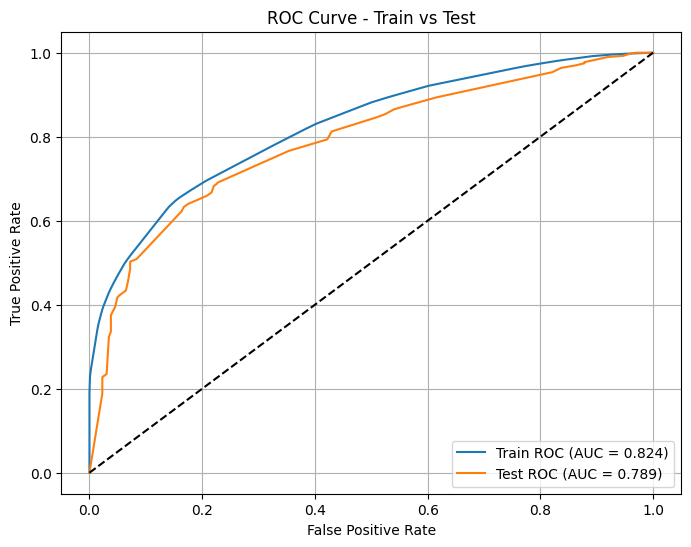


=== Evaluation for model: dt_2 ===
TRAIN SET METRICS:
 Accuracy : 0.785
 Precision: 0.845
 Recall   : 0.875
 F1 Score : 0.860
 AUC      : 0.828

TEST SET METRICS:
 Accuracy : 0.752
 Precision: 0.826
 Recall   : 0.850
 F1 Score : 0.838
 AUC      : 0.754



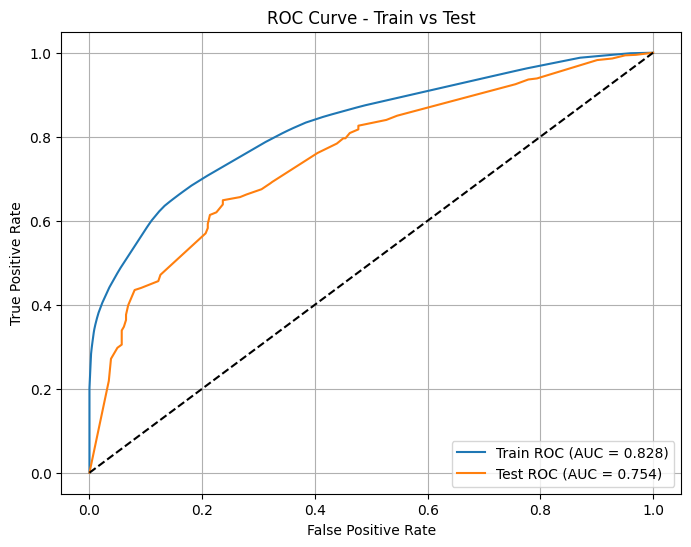


=== Evaluation for model: dt_3 ===
TRAIN SET METRICS:
 Accuracy : 0.784
 Precision: 0.818
 Recall   : 0.918
 F1 Score : 0.865
 AUC      : 0.826

TEST SET METRICS:
 Accuracy : 0.766
 Precision: 0.804
 Recall   : 0.912
 F1 Score : 0.855
 AUC      : 0.766



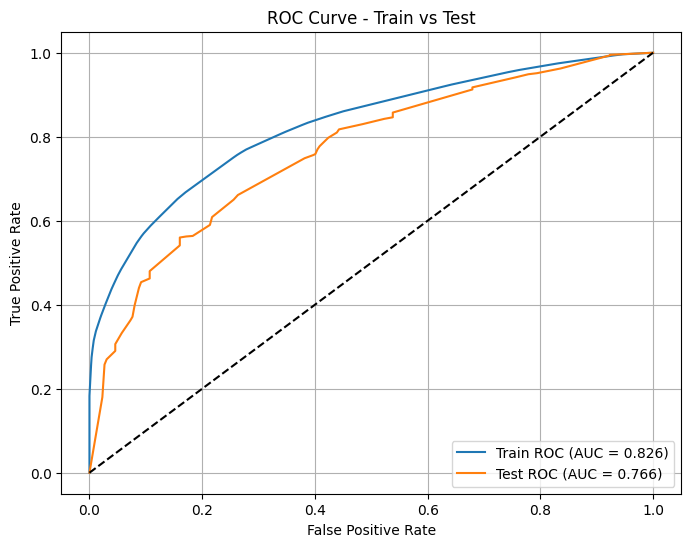


=== Evaluation for model: dt_4 ===
TRAIN SET METRICS:
 Accuracy : 0.783
 Precision: 0.816
 Recall   : 0.919
 F1 Score : 0.864
 AUC      : 0.817

TEST SET METRICS:
 Accuracy : 0.756
 Precision: 0.798
 Recall   : 0.905
 F1 Score : 0.848
 AUC      : 0.792



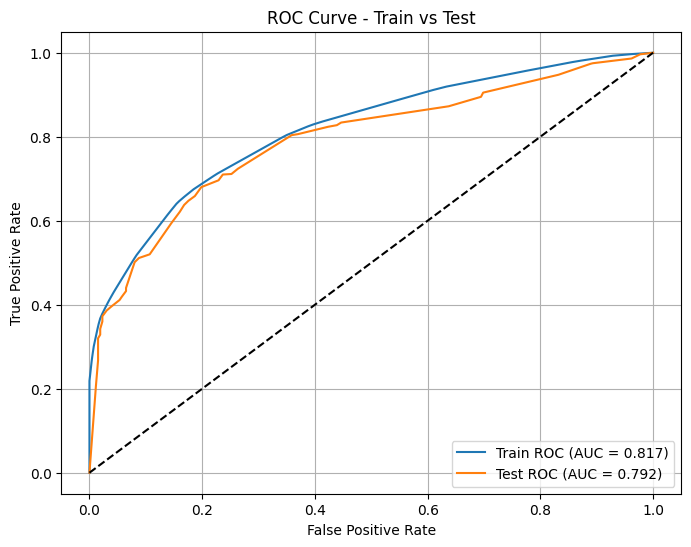


=== Evaluation for model: dt_5 ===
TRAIN SET METRICS:
 Accuracy : 0.784
 Precision: 0.811
 Recall   : 0.931
 F1 Score : 0.867
 AUC      : 0.825

TEST SET METRICS:
 Accuracy : 0.762
 Precision: 0.795
 Recall   : 0.920
 F1 Score : 0.853
 AUC      : 0.779



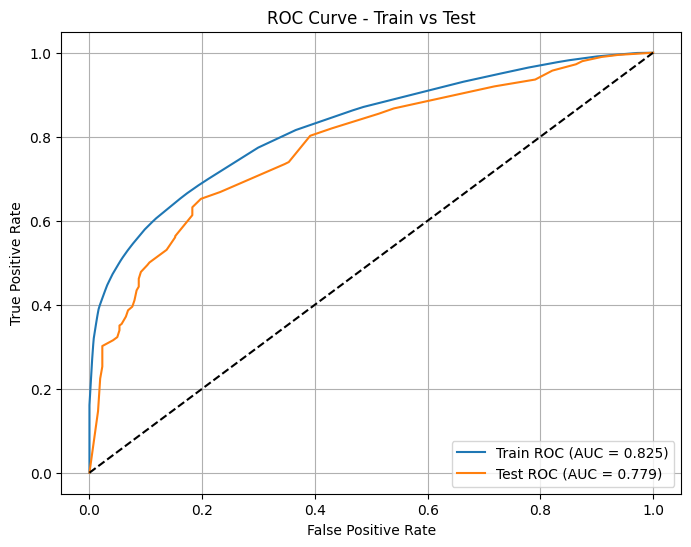

In [44]:
for model_name, model_dict in dt_models.items():
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    y_train = y.iloc[model_dict["train_index"]]
    X_test  = X.iloc[model_dict["test_index"]]
    y_test  = y.iloc[model_dict["test_index"]]

    print(f"\n=== Evaluation for model: {model_name} ===")
    evaluate_classifier(model, X_train, y_train, X_test, y_test)


=== Evaluation for model: xgb_1 ===
TRAIN SET METRICS:
 Accuracy : 0.769
 Precision: 0.768
 Recall   : 0.994
 F1 Score : 0.867
 AUC      : 0.827

TEST SET METRICS:
 Accuracy : 0.766
 Precision: 0.767
 Recall   : 0.990
 F1 Score : 0.864
 AUC      : 0.811



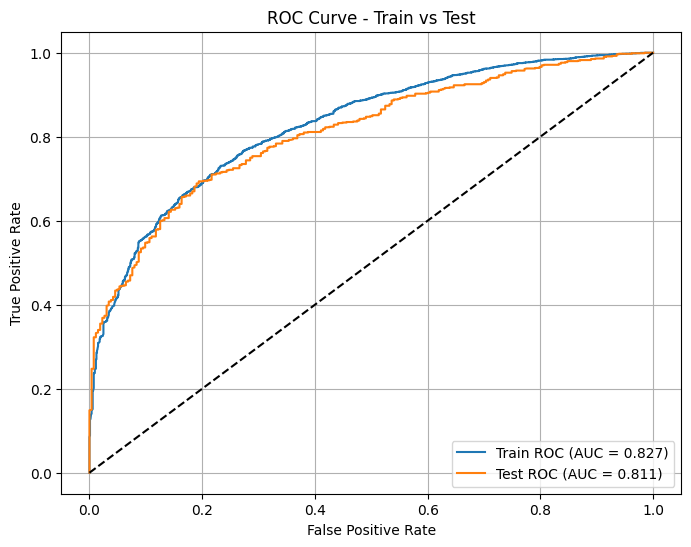


=== Evaluation for model: xgb_2 ===
TRAIN SET METRICS:
 Accuracy : 0.772
 Precision: 0.770
 Recall   : 0.995
 F1 Score : 0.868
 AUC      : 0.831

TEST SET METRICS:
 Accuracy : 0.767
 Precision: 0.768
 Recall   : 0.991
 F1 Score : 0.865
 AUC      : 0.778



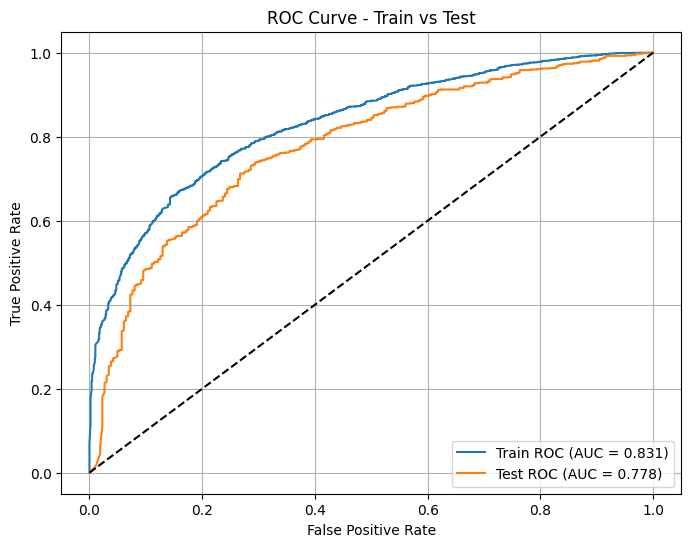


=== Evaluation for model: xgb_3 ===
TRAIN SET METRICS:
 Accuracy : 0.768
 Precision: 0.766
 Recall   : 0.995
 F1 Score : 0.866
 AUC      : 0.829

TEST SET METRICS:
 Accuracy : 0.763
 Precision: 0.764
 Recall   : 0.991
 F1 Score : 0.863
 AUC      : 0.794



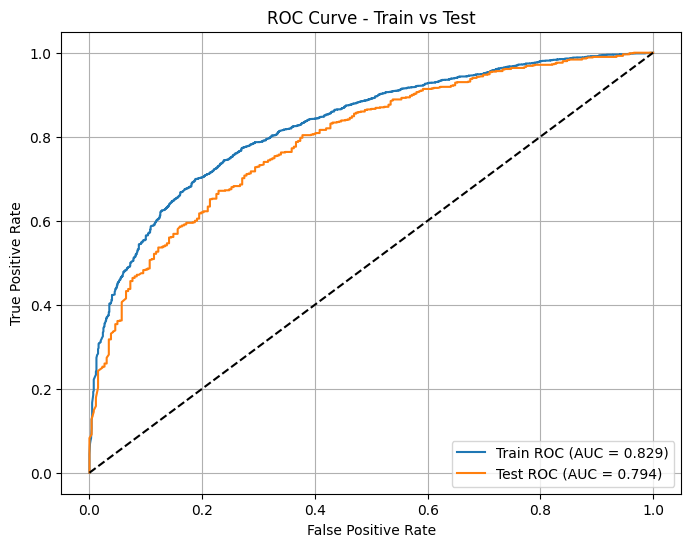


=== Evaluation for model: xgb_4 ===
TRAIN SET METRICS:
 Accuracy : 0.770
 Precision: 0.768
 Recall   : 0.995
 F1 Score : 0.867
 AUC      : 0.829

TEST SET METRICS:
 Accuracy : 0.761
 Precision: 0.761
 Recall   : 0.995
 F1 Score : 0.862
 AUC      : 0.816



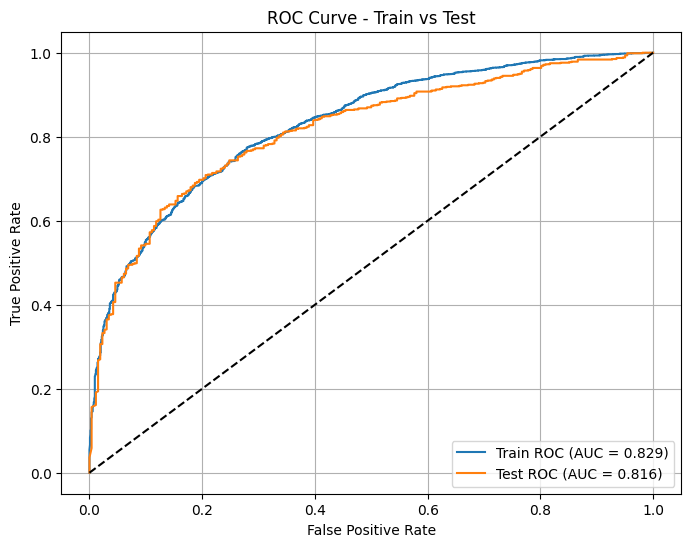


=== Evaluation for model: xgb_5 ===
TRAIN SET METRICS:
 Accuracy : 0.769
 Precision: 0.767
 Recall   : 0.996
 F1 Score : 0.867
 AUC      : 0.833

TEST SET METRICS:
 Accuracy : 0.765
 Precision: 0.765
 Recall   : 0.991
 F1 Score : 0.864
 AUC      : 0.800



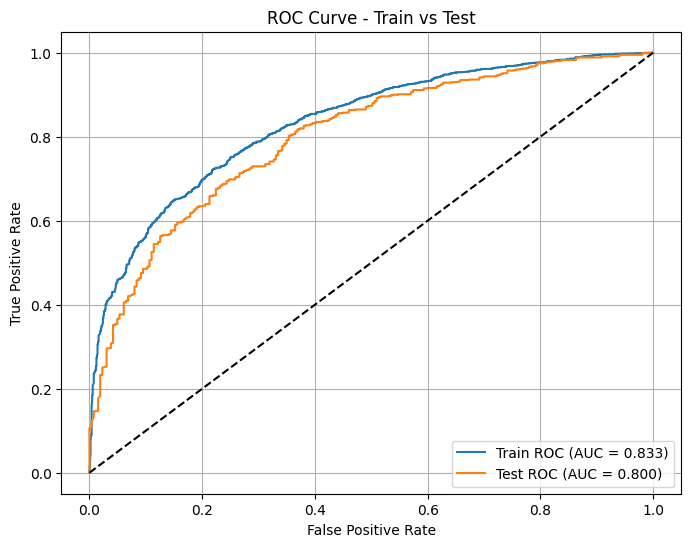

In [45]:
for model_name, model_dict in xgb_models.items():
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    y_train = y.iloc[model_dict["train_index"]]
    X_test  = X.iloc[model_dict["test_index"]]
    y_test  = y.iloc[model_dict["test_index"]]

    print(f"\n=== Evaluation for model: {model_name} ===")
    evaluate_classifier(model, X_train, y_train, X_test, y_test)


=== Evaluation for model: rf_1 ===
TRAIN SET METRICS:
 Accuracy : 0.787
 Precision: 0.791
 Recall   : 0.975
 F1 Score : 0.873
 AUC      : 0.828

TEST SET METRICS:
 Accuracy : 0.772
 Precision: 0.783
 Recall   : 0.965
 F1 Score : 0.865
 AUC      : 0.811



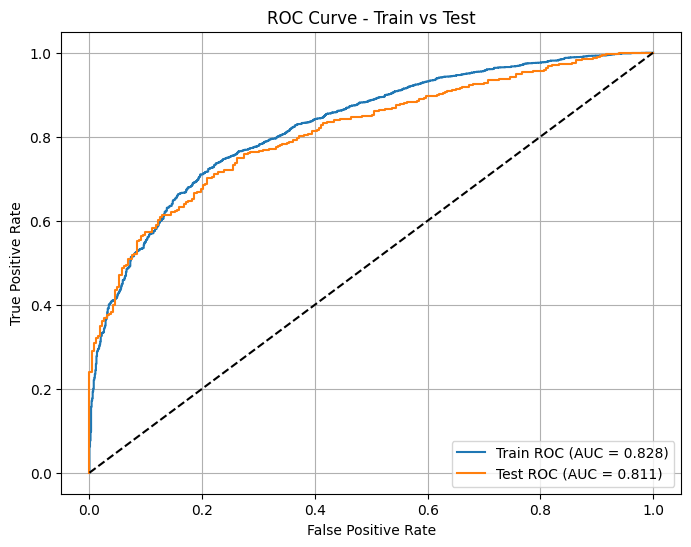


=== Evaluation for model: rf_2 ===
TRAIN SET METRICS:
 Accuracy : 0.786
 Precision: 0.791
 Recall   : 0.974
 F1 Score : 0.873
 AUC      : 0.833

TEST SET METRICS:
 Accuracy : 0.783
 Precision: 0.790
 Recall   : 0.970
 F1 Score : 0.871
 AUC      : 0.784



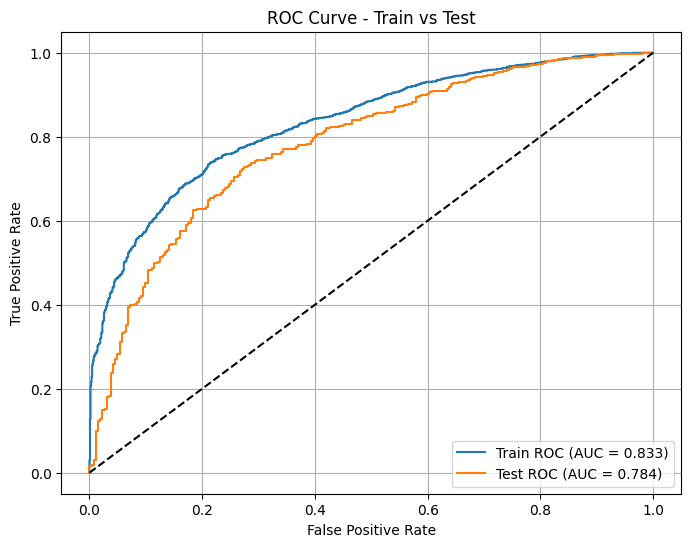


=== Evaluation for model: rf_3 ===
TRAIN SET METRICS:
 Accuracy : 0.787
 Precision: 0.788
 Recall   : 0.981
 F1 Score : 0.874
 AUC      : 0.831

TEST SET METRICS:
 Accuracy : 0.776
 Precision: 0.786
 Recall   : 0.966
 F1 Score : 0.867
 AUC      : 0.796



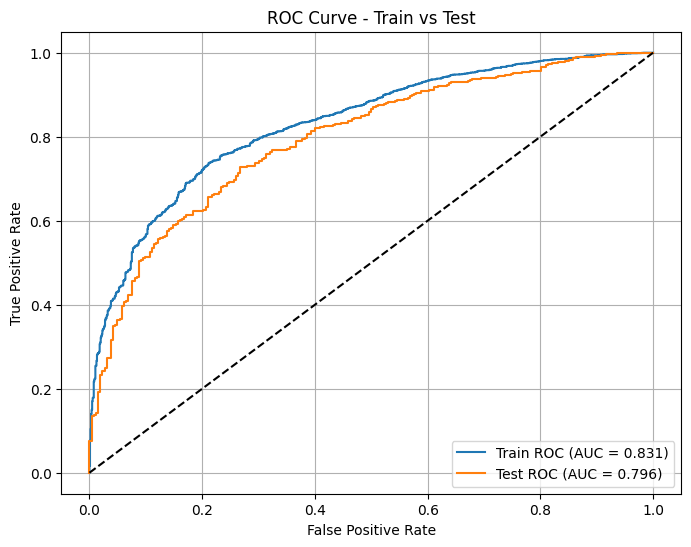


=== Evaluation for model: rf_4 ===
TRAIN SET METRICS:
 Accuracy : 0.787
 Precision: 0.790
 Recall   : 0.976
 F1 Score : 0.873
 AUC      : 0.829

TEST SET METRICS:
 Accuracy : 0.772
 Precision: 0.781
 Recall   : 0.969
 F1 Score : 0.865
 AUC      : 0.812



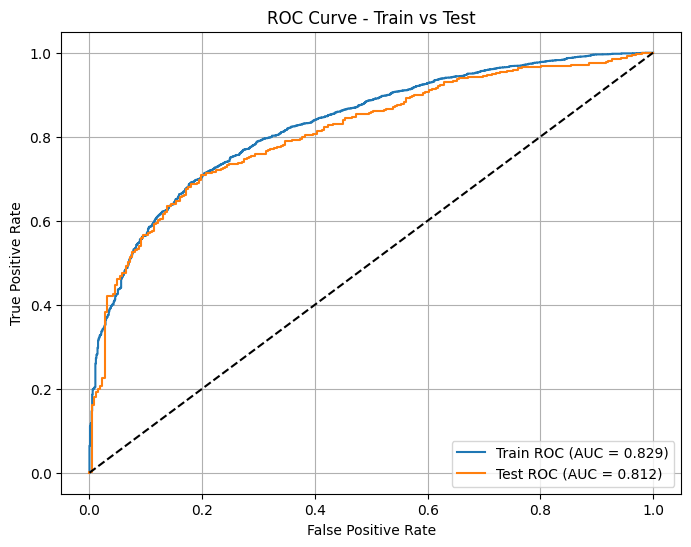


=== Evaluation for model: rf_5 ===
TRAIN SET METRICS:
 Accuracy : 0.784
 Precision: 0.790
 Recall   : 0.971
 F1 Score : 0.871
 AUC      : 0.830

TEST SET METRICS:
 Accuracy : 0.781
 Precision: 0.784
 Recall   : 0.977
 F1 Score : 0.870
 AUC      : 0.809



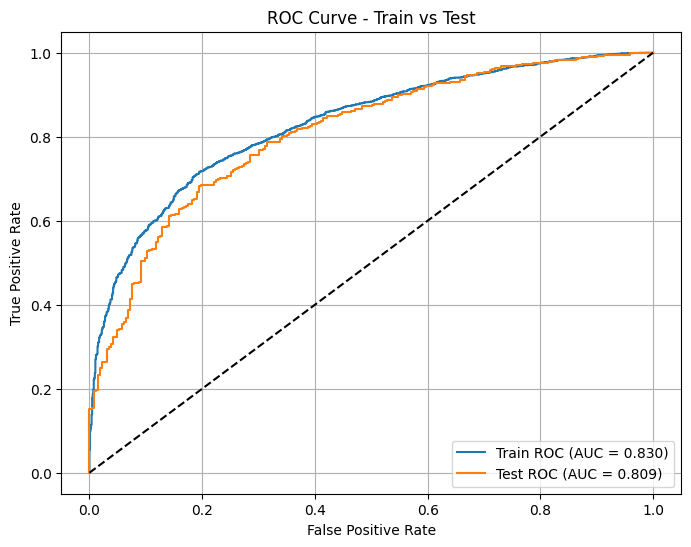

In [46]:
for model_name, model_dict in rf_models.items():
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    y_train = y.iloc[model_dict["train_index"]]
    X_test  = X.iloc[model_dict["test_index"]]
    y_test  = y.iloc[model_dict["test_index"]]

    print(f"\n=== Evaluation for model: {model_name} ===")
    evaluate_classifier(model, X_train, y_train, X_test, y_test)

## 7.2 AUC results (aggregated)

In [54]:
results = []

for model_name, model_dict in dt_models.items():
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    y_train = y.iloc[model_dict["train_index"]]
    X_test  = X.iloc[model_dict["test_index"]]
    y_test  = y.iloc[model_dict["test_index"]]

    # predicted probabilities for positive class
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    # compute AUC
    auc_train = roc_auc_score(y_train, y_train_proba)
    auc_test  = roc_auc_score(y_test, y_test_proba)

    # store results
    results.append({
        "Fold": model_name,
        "AUC_Train": auc_train,
        "AUC_Test": auc_test
    })

# convert to DataFrame
df_result_dt = pd.DataFrame(results)
df_result_dt

,Fold,AUC_Train,AUC_Test
0,dt_1,0.824185,0.789385
1,dt_2,0.827547,0.754406
2,dt_3,0.825655,0.765716
3,dt_4,0.817432,0.792490
4,dt_5,0.825485,0.779408


In [55]:
print(df_result_dt['AUC_Train'].mean())
print(df_result_dt['AUC_Test'].mean())

0.8240606951723823
0.7762809639259514


In [56]:
results = []

for model_name, model_dict in xgb_models.items():
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    y_train = y.iloc[model_dict["train_index"]]
    X_test  = X.iloc[model_dict["test_index"]]
    y_test  = y.iloc[model_dict["test_index"]]

    # predicted probabilities for positive class
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    # compute AUC
    auc_train = roc_auc_score(y_train, y_train_proba)
    auc_test  = roc_auc_score(y_test, y_test_proba)

    # store results
    results.append({
        "Fold": model_name,
        "AUC_Train": auc_train,
        "AUC_Test": auc_test
    })

# convert to DataFrame
df_result_xgb = pd.DataFrame(results)
df_result_xgb

,Fold,AUC_Train,AUC_Test
0,xgb_1,0.827449,0.811088
1,xgb_2,0.831399,0.778290
2,xgb_3,0.829031,0.794146
3,xgb_4,0.828722,0.816088
4,xgb_5,0.832941,0.800157


In [57]:
print(df_result_xgb['AUC_Train'].mean())
print(df_result_xgb['AUC_Test'].mean())

0.8299083245028106
0.7999536690862744


In [58]:
results = []

for model_name, model_dict in rf_models.items():
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    y_train = y.iloc[model_dict["train_index"]]
    X_test  = X.iloc[model_dict["test_index"]]
    y_test  = y.iloc[model_dict["test_index"]]

    # predicted probabilities for positive class
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    # compute AUC
    auc_train = roc_auc_score(y_train, y_train_proba)
    auc_test  = roc_auc_score(y_test, y_test_proba)

    # store results
    results.append({
        "Fold": model_name,
        "AUC_Train": auc_train,
        "AUC_Test": auc_test
    })

# convert to DataFrame
df_result_rf = pd.DataFrame(results)
df_result_rf

,Fold,AUC_Train,AUC_Test
0,rf_1,0.828131,0.811155
1,rf_2,0.833235,0.783507
2,rf_3,0.831256,0.796283
3,rf_4,0.828837,0.811589
4,rf_5,0.830228,0.808768


In [59]:
print(df_result_rf['AUC_Train'].mean())
print(df_result_rf['AUC_Test'].mean())

0.8303373781627845
0.8022602746537908


<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 8. Feature importance - SHAP </h1>

In [61]:
def compute_shap_importance(model, X: pd.DataFrame, fold_name: str, model_type: str, class_idx: int = 1) -> pd.DataFrame:
    """
    Calculate SHAP feature importance for single fold.
    
    Output DataFrame with columns: Feature, SHAP_Value, Fold, Model_Type
    """

    print(f"\nComputing SHAP importance for: {fold_name} ({model_type})")

    # TreeExplainer works for both XGBoost and sklearn models
    explainer = shap.TreeExplainer(model, data=X, model_output="raw")
    explanation = explainer(X)
    
    values = explanation.values
    
    # handle binary classification output
    if values.ndim == 3:
        values = values[:, :, class_idx]
    
    # global SHAP importance = mean |SHAP| across all samples
    importance = np.abs(values).mean(axis=0)
    
    df_shap = pd.DataFrame({
        "Feature": explanation.feature_names,
        "SHAP_Value": importance,
        "Fold": fold_name,
        "Model_Type": model_type
    })
    
    # opcjonalnie wykres bar plot dla folda
    shap.summary_plot(values, X, plot_type="bar", show=True)
    
    return df_shap


Computing SHAP importance for: dt_1 (DecisionTree)


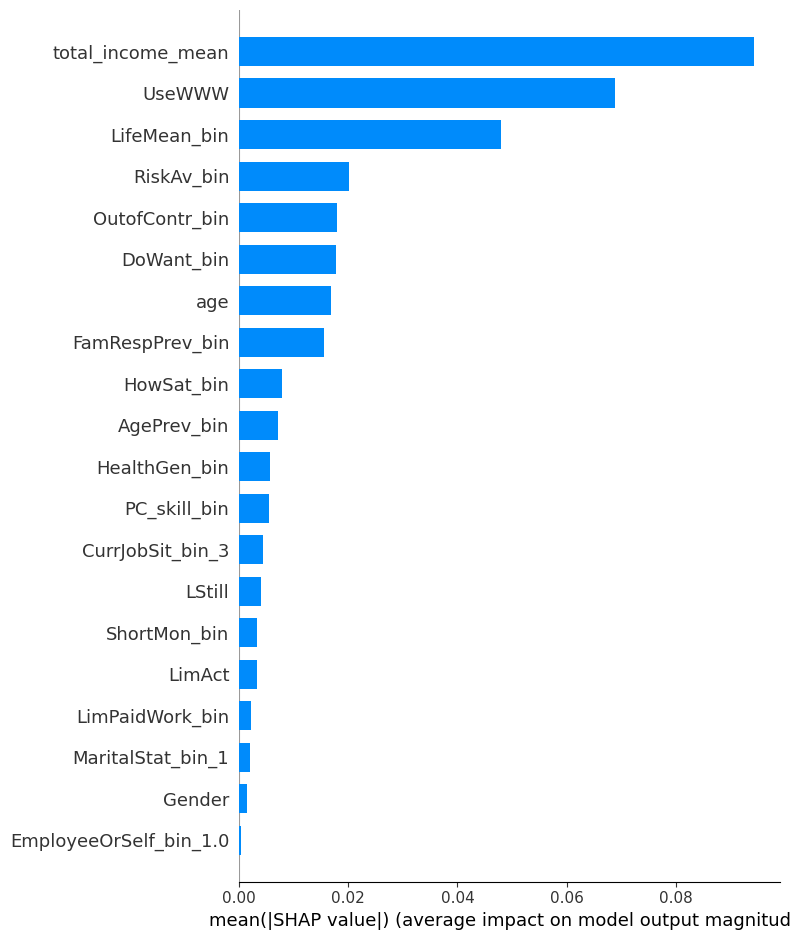


Computing SHAP importance for: dt_2 (DecisionTree)


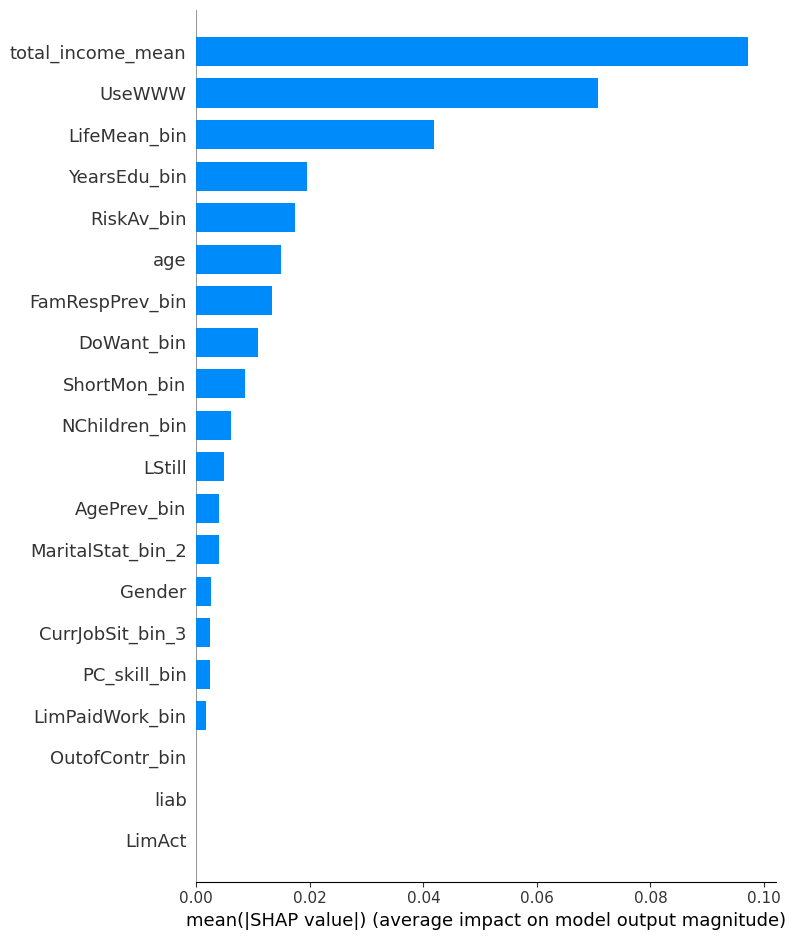


Computing SHAP importance for: dt_3 (DecisionTree)


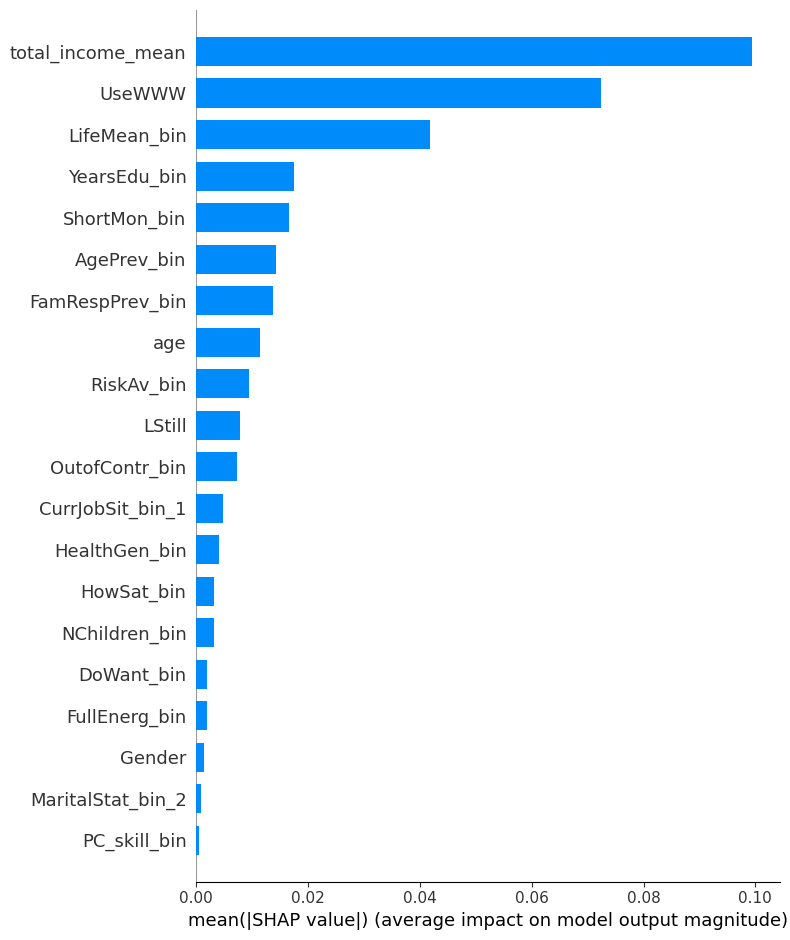


Computing SHAP importance for: dt_4 (DecisionTree)


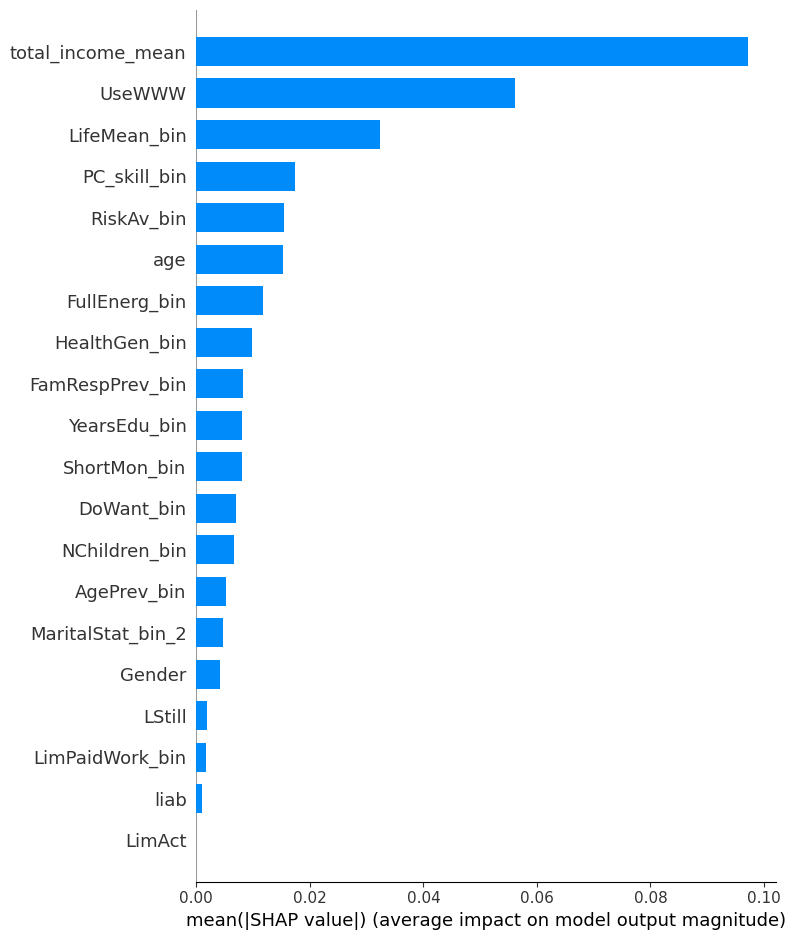


Computing SHAP importance for: dt_5 (DecisionTree)


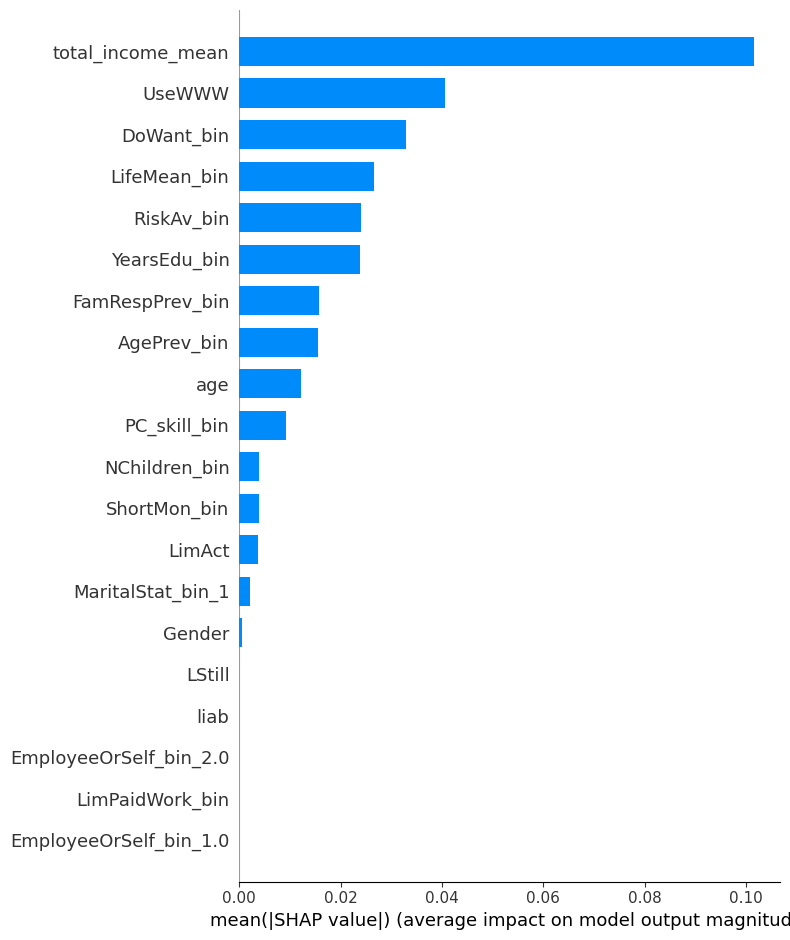

,Feature,SHAP_Value,Fold,Model_Type
0,total_income_mean,0.094391,dt_1,DecisionTree
1,Gender,0.001493,dt_1,DecisionTree
2,age,0.016805,dt_1,DecisionTree
3,UseWWW,0.068849,dt_1,DecisionTree
4,LStill,0.003972,dt_1,DecisionTree
...,...,...,...,...
205,CurrJobSit_bin_3,0.000000,dt_5,DecisionTree
206,EmployeeOrSelf_bin_1.0,0.000000,dt_5,DecisionTree
207,EmployeeOrSelf_bin_2.0,0.000000,dt_5,DecisionTree
208,EmployeeOrSelf_bin_3.0,0.000000,dt_5,DecisionTree


In [62]:
shap_folds = []

for i, (fold_name, model_dict) in enumerate(dt_models.items(), start=1):
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    
    shap_df = compute_shap_importance(
        model=model,
        X=X_train,
        fold_name=fold_name,
        model_type="DecisionTree"
    )
    
    globals()[f"shap_importance_{fold_name}"] = shap_df
    shap_folds.append(shap_df)

shap_importance_dt = pd.concat(shap_folds, ignore_index=True)
shap_importance_dt


Computing SHAP importance for: xgb_1 (XGBoost)


 99%|===================| 4213/4248 [00:47<00:00]        

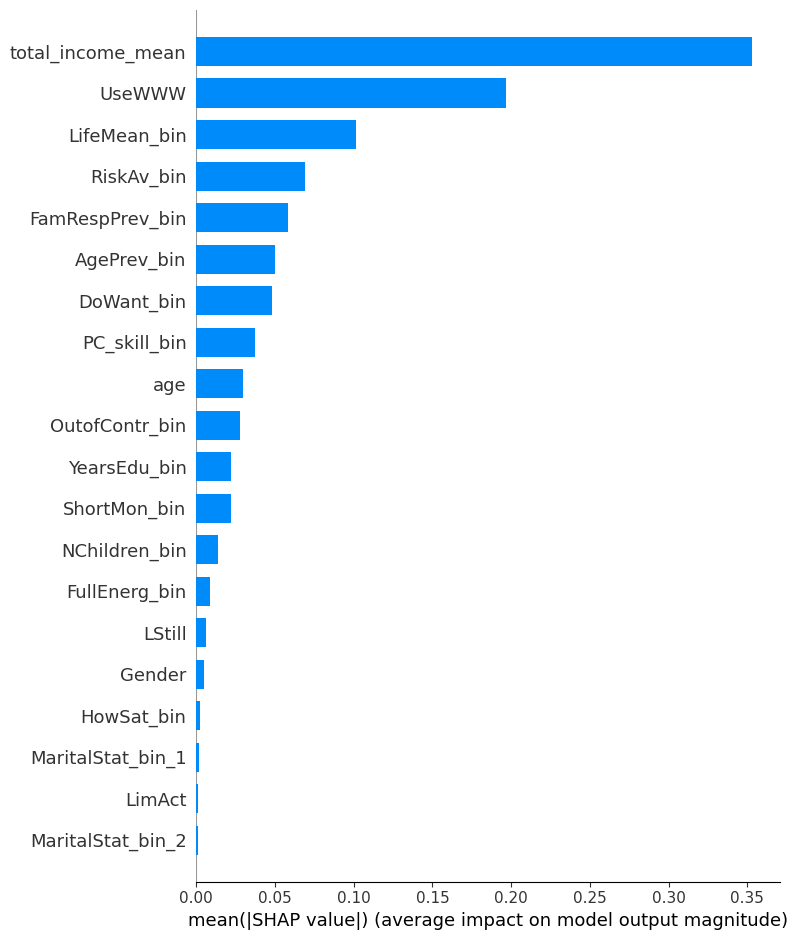


Computing SHAP importance for: xgb_2 (XGBoost)


 97%|=================== | 4118/4249 [00:33<00:01]       

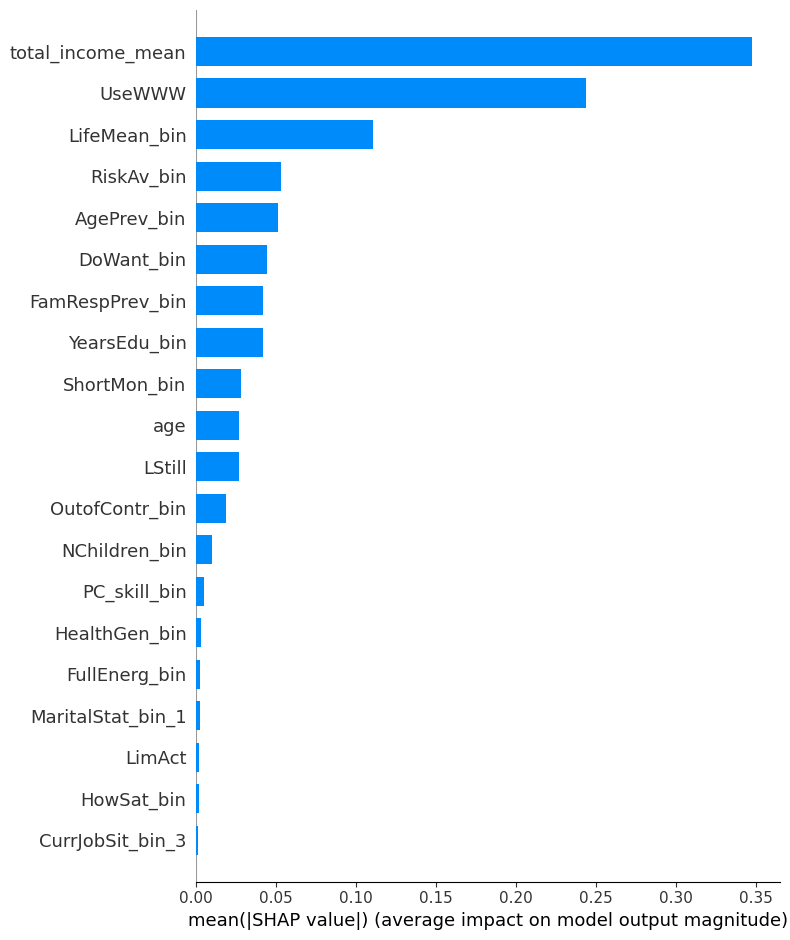


Computing SHAP importance for: xgb_3 (XGBoost)


100%|===================| 4245/4249 [00:36<00:00]        

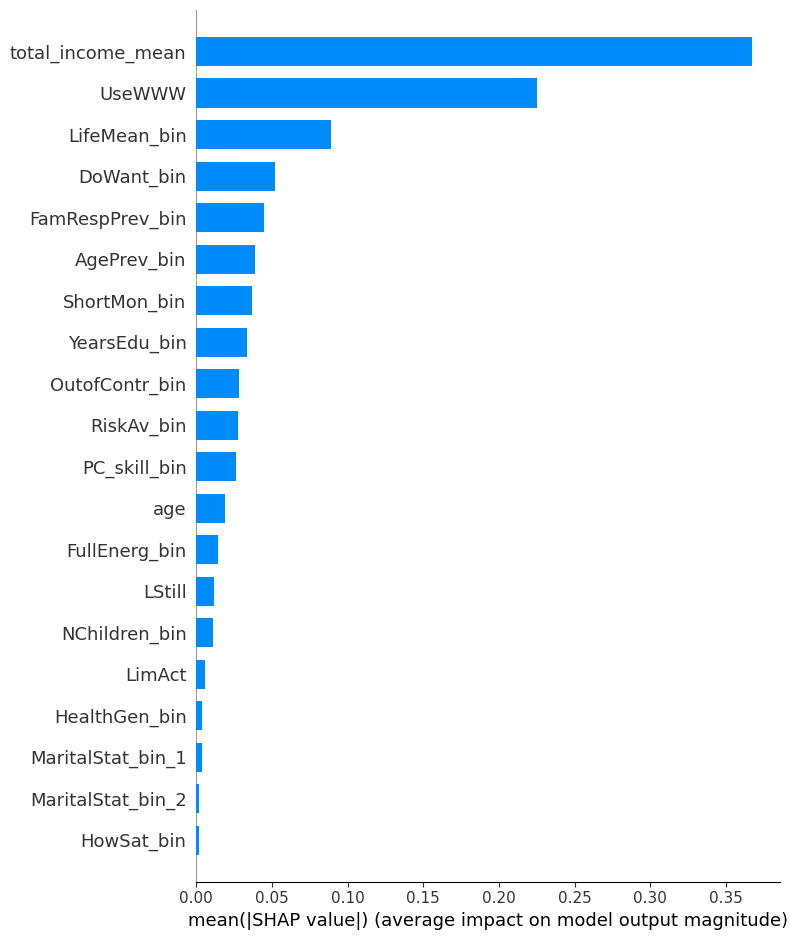


Computing SHAP importance for: xgb_4 (XGBoost)


 97%|=================== | 4129/4249 [00:43<00:01]       

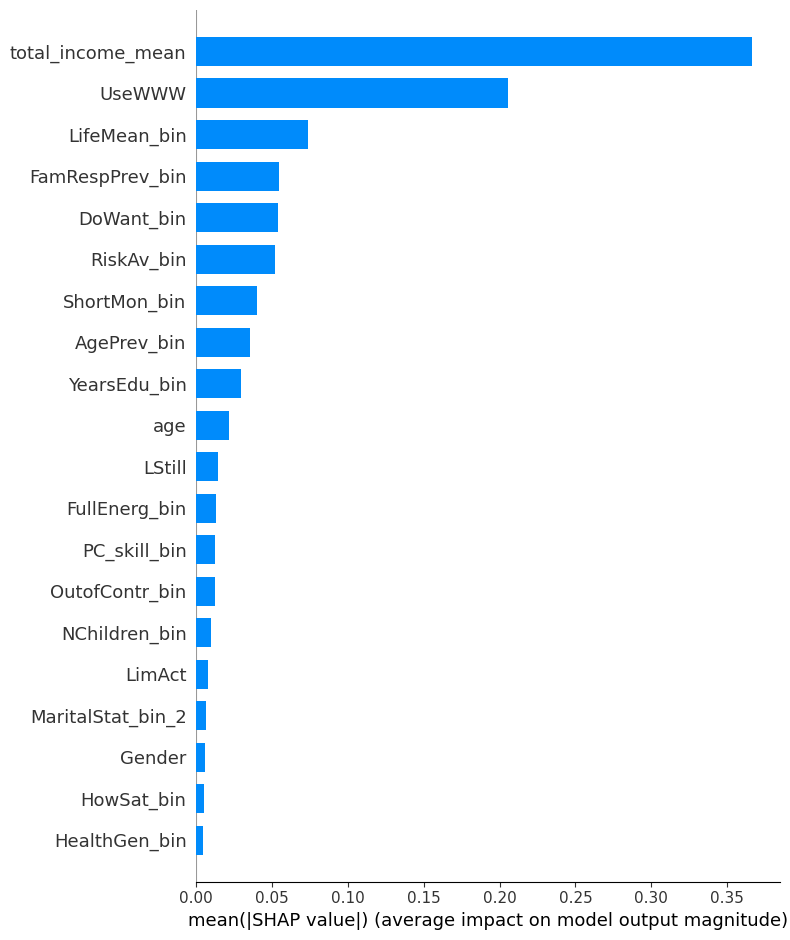


Computing SHAP importance for: xgb_5 (XGBoost)


 98%|===================| 4145/4249 [00:33<00:00]        

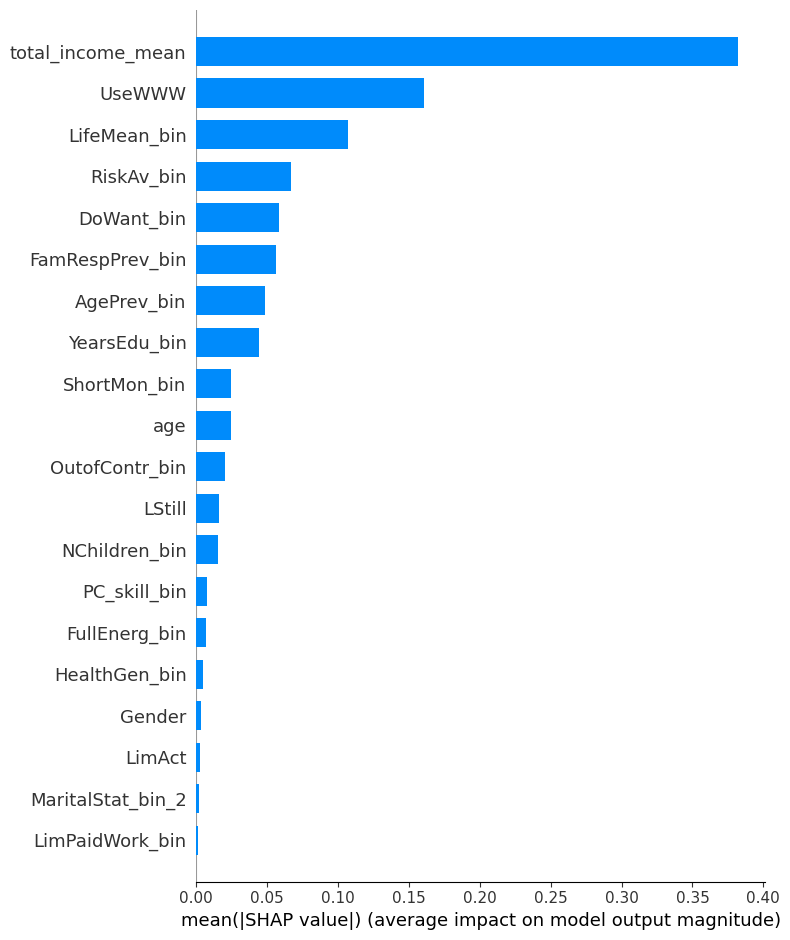

,Feature,SHAP_Value,Fold,Model_Type
0,total_income_mean,0.353146,xgb_1,XGBoost
1,Gender,0.004766,xgb_1,XGBoost
2,age,0.029786,xgb_1,XGBoost
3,UseWWW,0.196523,xgb_1,XGBoost
4,LStill,0.006446,xgb_1,XGBoost
...,...,...,...,...
205,CurrJobSit_bin_3,0.000000,xgb_5,XGBoost
206,EmployeeOrSelf_bin_1.0,0.000000,xgb_5,XGBoost
207,EmployeeOrSelf_bin_2.0,0.000000,xgb_5,XGBoost
208,EmployeeOrSelf_bin_3.0,0.000000,xgb_5,XGBoost


In [63]:
shap_folds = []

for i, (fold_name, model_dict) in enumerate(xgb_models.items(), start=1):
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    
    shap_df = compute_shap_importance(
        model=model,
        X=X_train,
        fold_name=fold_name,
        model_type="XGBoost"
    )
    
    globals()[f"shap_importance_{fold_name}"] = shap_df
    shap_folds.append(shap_df)

shap_importance_xgb = pd.concat(shap_folds, ignore_index=True)
shap_importance_xgb


Computing SHAP importance for: rf_1 (RandomForest)


100%|===================| 8493/8496 [02:11<00:00]        

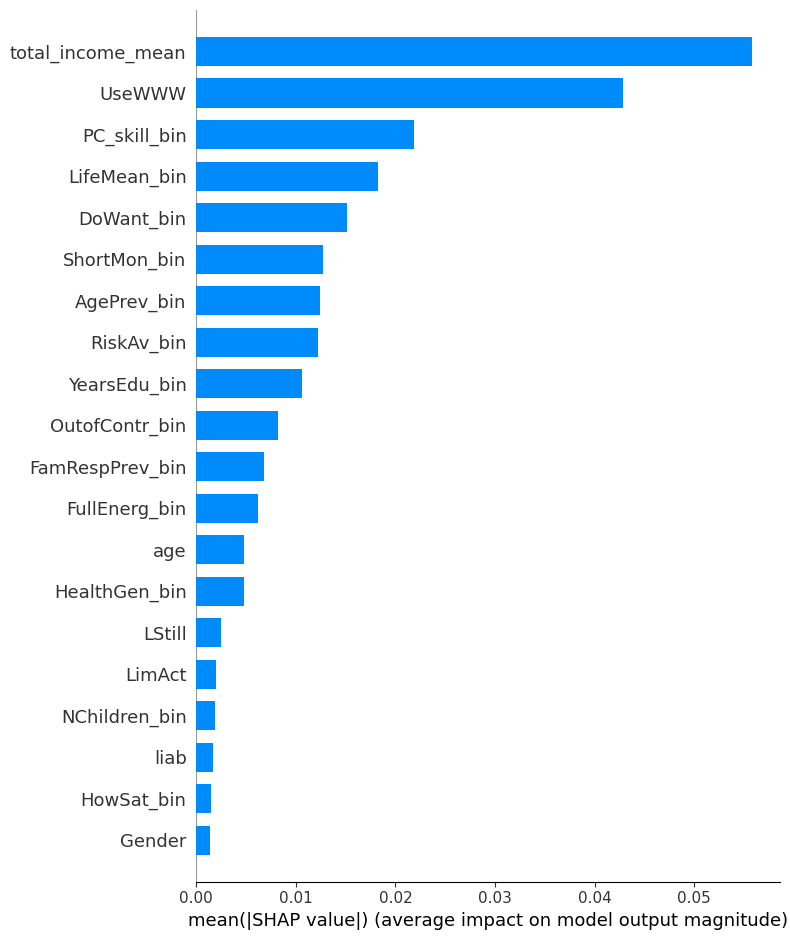


Computing SHAP importance for: rf_2 (RandomForest)


100%|===================| 8483/8498 [02:18<00:00]        

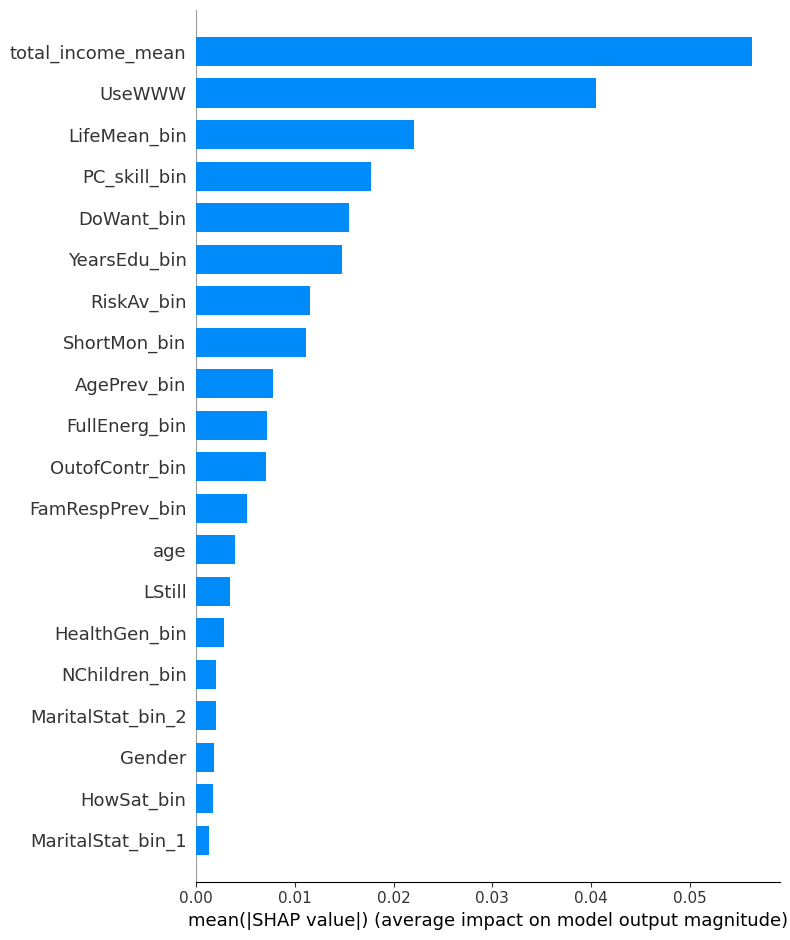


Computing SHAP importance for: rf_3 (RandomForest)


100%|===================| 8476/8498 [02:25<00:00]        

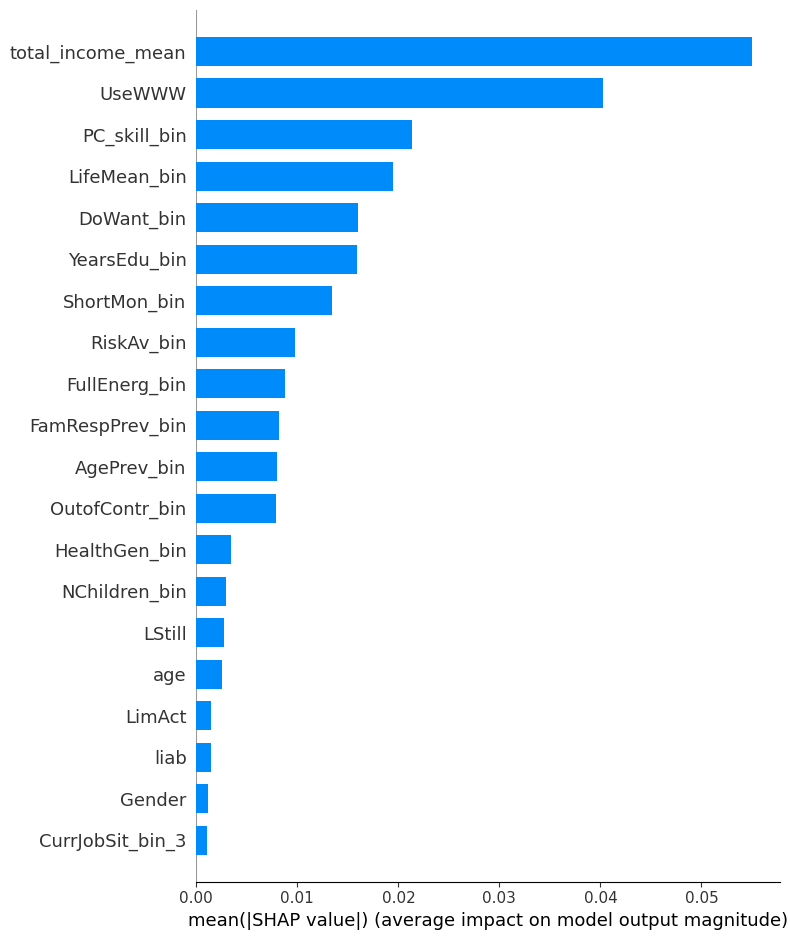


Computing SHAP importance for: rf_4 (RandomForest)


 99%|===================| 8420/8498 [02:13<00:01]        

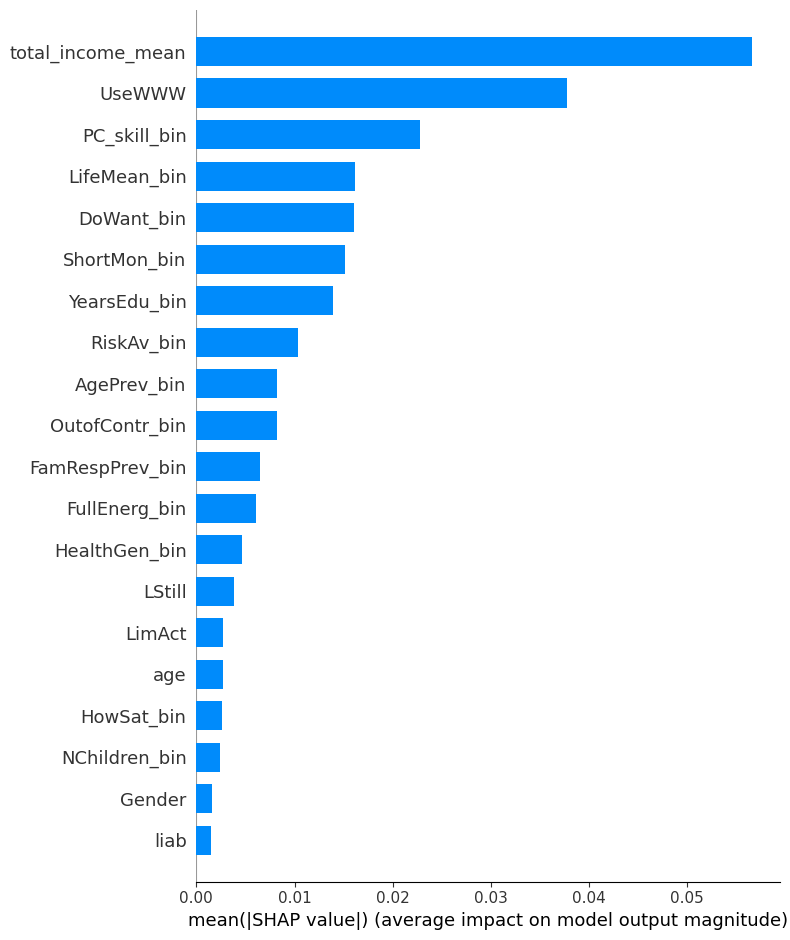


Computing SHAP importance for: rf_5 (RandomForest)


100%|===================| 8468/8498 [02:15<00:00]        

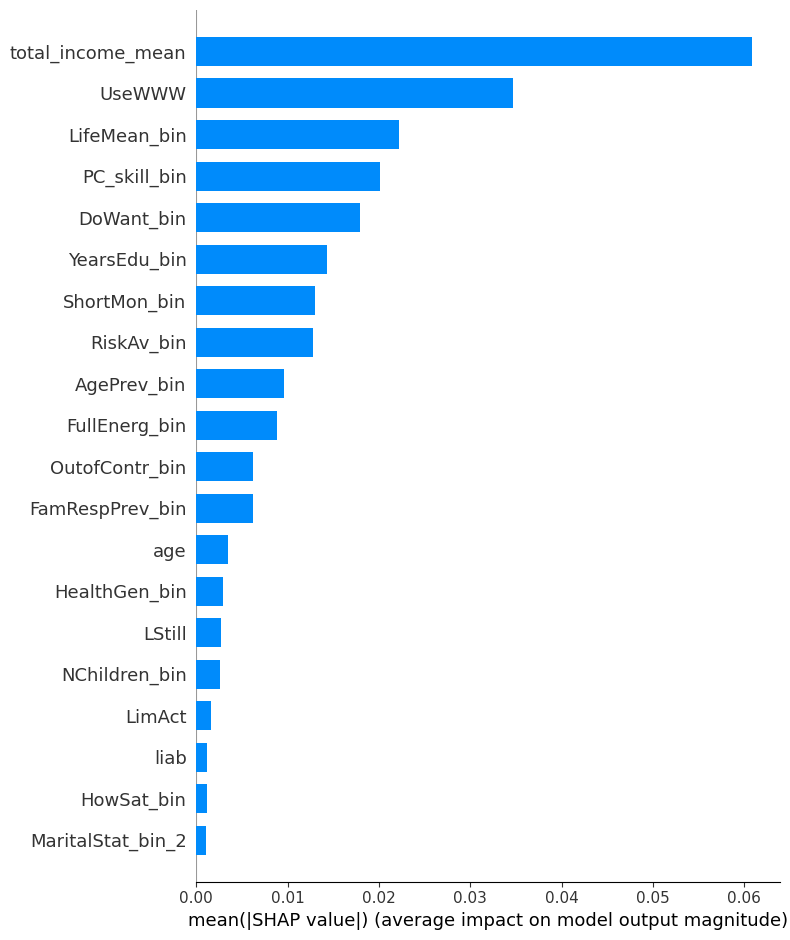

,Feature,SHAP_Value,Fold,Model_Type
0,total_income_mean,0.055823,rf_1,RandomForest
1,Gender,0.001363,rf_1,RandomForest
2,age,0.004779,rf_1,RandomForest
3,UseWWW,0.042840,rf_1,RandomForest
4,LStill,0.002465,rf_1,RandomForest
...,...,...,...,...
205,CurrJobSit_bin_3,0.001023,rf_5,RandomForest
206,EmployeeOrSelf_bin_1.0,0.000064,rf_5,RandomForest
207,EmployeeOrSelf_bin_2.0,0.000011,rf_5,RandomForest
208,EmployeeOrSelf_bin_3.0,0.000010,rf_5,RandomForest


In [64]:
shap_folds = []

for i, (fold_name, model_dict) in enumerate(rf_models.items(), start=1):
    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]
    
    shap_df = compute_shap_importance(
        model=model,
        X=X_train,
        fold_name=fold_name,
        model_type="RandomForest"
    )
    
    globals()[f"shap_importance_{fold_name}"] = shap_df
    shap_folds.append(shap_df)

shap_importance_rf = pd.concat(shap_folds, ignore_index=True)
shap_importance_rf

In [65]:
shap_importance_dt.to_excel('shap_dt_new.xlsx')
shap_importance_xgb.to_excel('shap_xgb_new.xlsx')
shap_importance_rf.to_excel('shap_rf_new.xlsx')

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;"> 9. Feature importance - MDI </h1>

In [66]:
def compute_mdi_importance(model, X: pd.DataFrame, fold_name: str, model_type: str) -> pd.DataFrame:
    """
    Computes MDI feature importance for a single fold.

    Output a DataFrame with columns: Feature, MDI_Value, Fold, Model_Type.
    """

    print(f"\nComputing MDI importance for: {fold_name} ({model_type})")

    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"Model {model_type} does not support feature_importances_")

    importance = model.feature_importances_

    df_mdi = pd.DataFrame({
        "Feature": X.columns,
        "MDI_Value": importance,
        "Fold": fold_name,
        "Model_Type": model_type
    })

    return df_mdi

In [67]:
mdi_folds = []

for fold_name, model_dict in dt_models.items():

    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]

    mdi_df = compute_mdi_importance(
        model=model,
        X=X_train,
        fold_name=fold_name,
        model_type="DecisionTree"
    )

    globals()[f"mdi_importance_{fold_name}"] = mdi_df
    mdi_folds.append(mdi_df)

mdi_importance_dt = pd.concat(mdi_folds, ignore_index=True)
mdi_importance_dt


Computing MDI importance for: dt_1 (DecisionTree)

Computing MDI importance for: dt_2 (DecisionTree)

Computing MDI importance for: dt_3 (DecisionTree)

Computing MDI importance for: dt_4 (DecisionTree)

Computing MDI importance for: dt_5 (DecisionTree)


,Feature,MDI_Value,Fold,Model_Type
0,total_income_mean,0.469186,dt_1,DecisionTree
1,Gender,0.010913,dt_1,DecisionTree
2,age,0.040384,dt_1,DecisionTree
3,UseWWW,0.180222,dt_1,DecisionTree
4,LStill,0.006946,dt_1,DecisionTree
...,...,...,...,...
205,CurrJobSit_bin_3,0.000000,dt_5,DecisionTree
206,EmployeeOrSelf_bin_1.0,0.000000,dt_5,DecisionTree
207,EmployeeOrSelf_bin_2.0,0.000000,dt_5,DecisionTree
208,EmployeeOrSelf_bin_3.0,0.000000,dt_5,DecisionTree


In [68]:
mdi_folds = []

for fold_name, model_dict in xgb_models.items():

    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]

    mdi_df = compute_mdi_importance(
        model=model,
        X=X_train,
        fold_name=fold_name,
        model_type="XGBoost"
    )

    globals()[f"mdi_importance_{fold_name}"] = mdi_df
    mdi_folds.append(mdi_df)

mdi_importance_xgb = pd.concat(mdi_folds, ignore_index=True)
mdi_importance_xgb


Computing MDI importance for: xgb_1 (XGBoost)

Computing MDI importance for: xgb_2 (XGBoost)

Computing MDI importance for: xgb_3 (XGBoost)

Computing MDI importance for: xgb_4 (XGBoost)

Computing MDI importance for: xgb_5 (XGBoost)


,Feature,MDI_Value,Fold,Model_Type
0,total_income_mean,0.183952,xgb_1,XGBoost
1,Gender,0.005309,xgb_1,XGBoost
2,age,0.024565,xgb_1,XGBoost
3,UseWWW,0.233465,xgb_1,XGBoost
4,LStill,0.021136,xgb_1,XGBoost
...,...,...,...,...
205,CurrJobSit_bin_3,0.000000,xgb_5,XGBoost
206,EmployeeOrSelf_bin_1.0,0.000000,xgb_5,XGBoost
207,EmployeeOrSelf_bin_2.0,0.000000,xgb_5,XGBoost
208,EmployeeOrSelf_bin_3.0,0.000000,xgb_5,XGBoost


In [69]:
mdi_folds = []

for fold_name, model_dict in rf_models.items():

    model = model_dict["model"]
    X_train = X.iloc[model_dict["train_index"]]

    mdi_df = compute_mdi_importance(
        model=model,
        X=X_train,
        fold_name=fold_name,
        model_type="RandomForest"
    )

    globals()[f"mdi_importance_{fold_name}"] = mdi_df
    mdi_folds.append(mdi_df)

mdi_importance_rf = pd.concat(mdi_folds, ignore_index=True)
mdi_importance_rf


Computing MDI importance for: rf_1 (RandomForest)

Computing MDI importance for: rf_2 (RandomForest)

Computing MDI importance for: rf_3 (RandomForest)

Computing MDI importance for: rf_4 (RandomForest)

Computing MDI importance for: rf_5 (RandomForest)


,Feature,MDI_Value,Fold,Model_Type
0,total_income_mean,0.276528,rf_1,RandomForest
1,Gender,0.006483,rf_1,RandomForest
2,age,0.031591,rf_1,RandomForest
3,UseWWW,0.163031,rf_1,RandomForest
4,LStill,0.006213,rf_1,RandomForest
...,...,...,...,...
205,CurrJobSit_bin_3,0.002452,rf_5,RandomForest
206,EmployeeOrSelf_bin_1.0,0.000495,rf_5,RandomForest
207,EmployeeOrSelf_bin_2.0,0.000099,rf_5,RandomForest
208,EmployeeOrSelf_bin_3.0,0.000112,rf_5,RandomForest


In [70]:
mdi_importance_dt.to_excel('mdi_dt_new.xlsx')
mdi_importance_xgb.to_excel('mdi_xgb_new.xlsx')
mdi_importance_rf.to_excel('mdi_rf_new.xlsx')

<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;">10. Kendall's W - ranking consistency </h1> 

In [71]:
def compute_kendall_w(importance_df):
    """
    Computes Kendall's coefficient of concordance (W) for feature importance rankings.

    Parameters
    ----------
    importance_df : pd.DataFrame
        Rows = features
        Columns = folds/models
        Values = feature importance scores

    Returns
    -------
    W : float
        Kendall's coefficient of concordance
    rank_matrix : pd.DataFrame
        Ranking of features for each run
    """

    # Number of objects (features) and judges (runs)
    n, m = importance_df.shape

    if m < 2:
        raise ValueError("Need at least 2 runs to compute Kendall's W.")

    # Convert importance values to ranks (descending importance)
    rank_matrix = importance_df.apply(lambda col: rankdata(-col, method="average"), axis=0)

    # Sum of ranks for each feature
    R = rank_matrix.sum(axis=1)

    # Mean rank sum
    R_bar = np.mean(R)

    # Compute S
    S = np.sum((R - R_bar) ** 2)

    # Kendall's W formula
    W = (12 * S) / (m**2 * (n**3 - n))

    return W, rank_matrix

## 10.1 Kendall's W based on SHAP importance

In [72]:
importance_wide_dt = shap_importance_dt.pivot_table(
    index="Feature",
    columns="Fold",
    values="SHAP_Value"
)

kendall_w_shap, rank_matrix = compute_kendall_w(
    importance_df=importance_wide_dt
)

print("Kendall W stability:", kendall_w_shap)

Kendall W stability: 0.6538011506360911


In [73]:
importance_wide_xgb = shap_importance_xgb.pivot_table(
    index="Feature",
    columns="Fold",
    values="SHAP_Value"
)

kendall_w_shap, rank_matrix = compute_kendall_w(
    importance_df=importance_wide_xgb
)

print("Kendall W stability:", kendall_w_shap)

Kendall W stability: 0.8872279393890284


In [74]:
importance_wide_rf = shap_importance_rf.pivot_table(
    index="Feature",
    columns="Fold",
    values="SHAP_Value"
)

kendall_w_shap, rank_matrix = compute_kendall_w(
    importance_df=importance_wide_rf
)

print("Kendall W stability:", kendall_w_shap)

Kendall W stability: 0.9670431893687708


## 10.2 Kendall's W based on MDI importance

In [75]:
importance_wide_dt = mdi_importance_dt.pivot_table(
    index="Feature",
    columns="Fold",
    values="MDI_Value"
)

kendall_w_mdi, rank_matrix = compute_kendall_w(
    importance_df=importance_wide_dt
)

print("Kendall W stability:", kendall_w_mdi)

Kendall W stability: 0.6733652054128515


In [76]:
importance_wide_xgb = mdi_importance_xgb.pivot_table(
    index="Feature",
    columns="Fold",
    values="MDI_Value"
)

kendall_w_mdi, rank_matrix = compute_kendall_w(
    importance_df=importance_wide_xgb
)

print("Kendall W stability:", kendall_w_mdi)

Kendall W stability: 0.8413775220808687


In [77]:
importance_wide_rf = mdi_importance_rf.pivot_table(
    index="Feature",
    columns="Fold",
    values="MDI_Value"
)

kendall_w_mdi, rank_matrix = compute_kendall_w(
    importance_df=importance_wide_rf
)

print("Kendall W stability:", kendall_w_mdi)

Kendall W stability: 0.9729227777327607


<a id="1"></a>
<h1 style="background-color: #2d6a4f; color: white; padding: 10px 16px; border-radius: 6px;">11. Final model - trained on full sample</h1> 

In [78]:
# same hyperparameters as previous
model_final = RandomForestClassifier(max_depth=6, n_estimators=100, criterion="entropy", min_samples_leaf=25, random_state=9401, n_jobs=-1)

# training
model_final.fit(X, y)


RandomForestClassifier(criterion='entropy', max_depth=6, min_samples_leaf=25,
                       n_jobs=-1, random_state=9401)

In [79]:
# predicted probabilities for positive class
y_proba = model.predict_proba(X)[:, 1]

# compute AUC
auc = roc_auc_score(y, y_proba)
auc

0.8260231978726389

## 11.1 SHAP importance - full sample


Computing SHAP importance for: full (RandomForest)


100%|===================| 10599/10622 [03:01<00:00]        

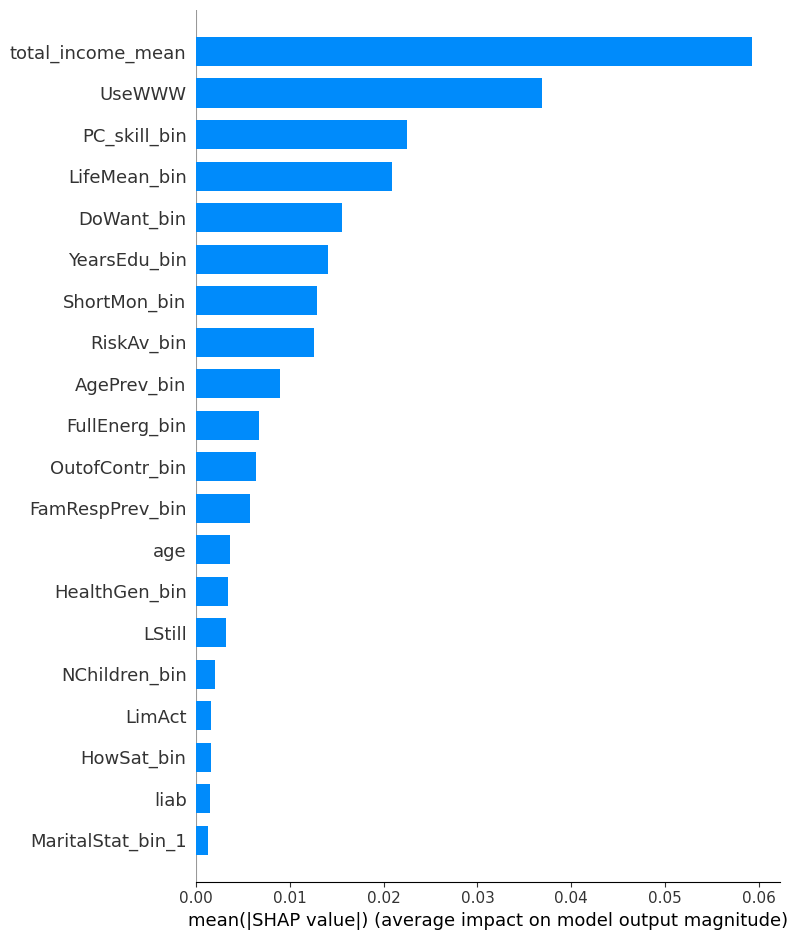

In [80]:
shap_df = compute_shap_importance(
    model=model_final,
    X=X,
    fold_name='full',
    model_type="RandomForest"
)

In [82]:
#shap_df

In [83]:
shap_df.to_excel('shap_model_final_new.xlsx')

## 11.2 MDI importance - full sample

In [84]:
mdi_df = compute_mdi_importance(
    model=model_final,
    X=X,
    fold_name='full',
    model_type="RandomForest"
)
#mdi_df


Computing MDI importance for: full (RandomForest)


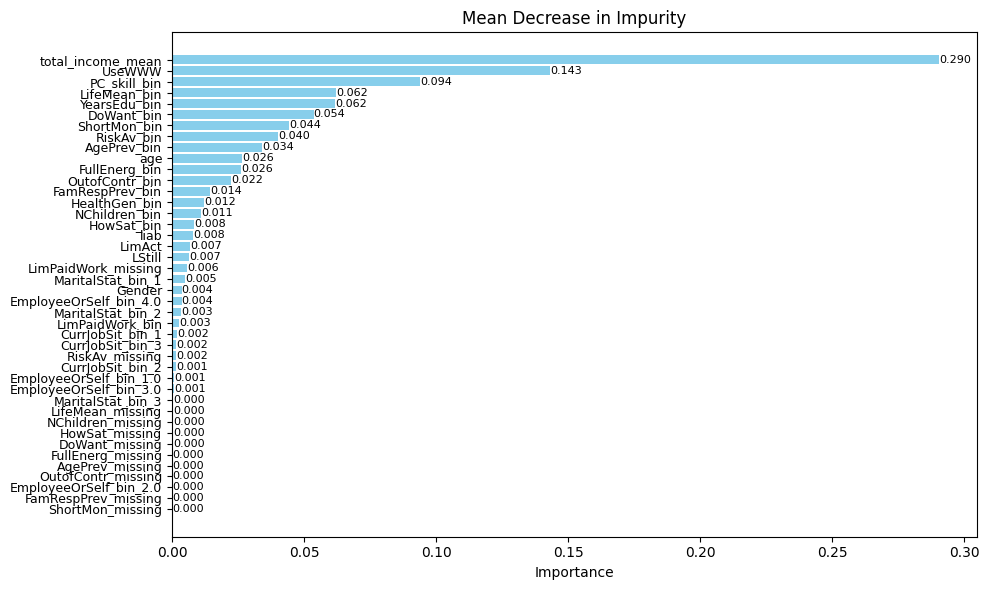

In [86]:
rf_importance = print_feature_importances_random_forest(model_final, X)

In [87]:
mdi_df.to_excel('mdi_model_final_new.xlsx')